In [223]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sys, os, pickle
from scipy.optimize import curve_fit

current_dir = '/home/marian/CIGAR_ANALYSIS/CIGAR/notebooks'
functions_path = os.path.abspath(os.path.join(current_dir, '../functions'))
sys.path.append(functions_path)
import parse_data
import cigar as cig
from tqdm import tqdm


##  Signal time constants

In [224]:
# Wong (2011) colorblind-safe palette
CB_COLORS = [
    '#000000',  # Black
    '#E69F00',  # Orange
    '#56B4E9',  # Sky blue
    '#009E73',  # Bluish green
    '#F0E442',  # Yellow
    '#0072B2',  # Blue
    '#D55E00',  # Vermillion
    '#CC79A7',  # Reddish purple
    '#994F00',  # Brown
    '#006CD1',  # Cerulean
]

# Grayscale palette
GS_COLORS = [
    '#000000',  # Black
    '#1a1a1a',  # Near black
    '#333333',  # Very dark gray
    '#4d4d4d',  # Dark gray
    '#666666',  # Medium dark gray
    '#808080',  # Medium gray
    '#999999',  # Medium light gray
    '#b3b3b3',  # Light gray
    '#cccccc',  # Very light gray
    '#e6e6e6',  # Near white (use only on dark backgrounds)
]

# Classic palette — restores the original notebook look
CLASSIC_COLORS = [
    'royalblue', 'crimson', 'black', 'green',
    'darkorange', 'brown', 'coral', 'indigo', 'magenta', 'blue',
]

# colors = CB_COLORS
colors = GS_COLORS

CB_MARKERS    = ['o', 's', '^', 'D', 'v', 'P', '*', 'X']
CB_LINESTYLES = ['-', '--', '-.', ':', '-', '--', '-.', ':', '-', '--', '-.', ':']


In [225]:
font_size = 20
plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.size'] = font_size


In [226]:
base = "/home/marian/CIGAR_ANALYSIS/CIGAR/data"


##  Functions

In [227]:
def _rise_decay_normalised(t, t0, rise, decay):
    """Unit-area (1-exp)*exp pulse anchored at t0, zero for t < t0."""
    s = np.zeros_like(t, dtype=float)
    mask = t >= t0
    s[mask] = (1.0 - np.exp(-(t[mask]-t0) / rise)) * np.exp(-(t[mask]-t0) / decay)
    area = np.trapz(s, x=t)
    return s / (area if area != 0 else 1.0)


In [228]:
def ResponseSiPM(q_in_pes, t, t0, rise_time, decay_time, baseline=0.0):
    """SiPM single-PE pulse: area-normalised (1-exp)*exp, scaled by q_in_pes."""
    return q_in_pes * _rise_decay_normalised(t, t0, rise_time, decay_time) + baseline


In [229]:
def _check_bounds(popt, bounds_ch, label, names):
    """Check if any fitted parameter landed within 1% of its hard bounds."""
    tol = 0.01
    for i, (p, lo, hi) in enumerate(zip(popt, bounds_ch[0], bounds_ch[1])):
        span = (hi - lo) if not np.isinf(hi) else None
        if span is not None:
            if np.abs(p - lo) < tol * span:
                print(f'  ⚠ [{label}] {names[i]:12s} hit lower bound: value={p:.4e}  lower={lo:.4e}')
            elif np.abs(p - hi) < tol * span:
                print(f'  ⚠ [{label}] {names[i]:12s} hit upper bound: value={p:.4e}  upper={hi:.4e}')
        else:
            if p > 0 and np.abs(p - lo) / p < tol:
                print(f'  ⚠ [{label}] {names[i]:12s} hit lower bound: value={p:.4e}  lower={lo:.4e}')


In [230]:
def _I(p, q, u):
    """I(p,q,u) = integral_0^u exp(-p*s)*exp(-q*(u-s)) ds.
    Returns (exp(-p*u)-exp(-q*u))/(q-p) if p!=q, else u*exp(-p*u).
    """
    if np.abs(p - q) < 1e-30:
        return u * np.exp(-p * u)
    return (np.exp(-p * u) - np.exp(-q * u)) / (q - p)


In [231]:
def _conv_two_rise_decay(u, rise1, decay1, rise2, decay2):
    """Analytical convolution of two (1-exp)*exp pulses starting at u=0.
    h(u) = I(a,c,u) - I(a,d,u) - I(b,c,u) + I(b,d,u)
    with a=1/decay1, b=1/rise1+1/decay1, c=1/decay2, d=1/rise2+1/decay2.
    """
    a = 1.0 / decay1
    b = 1.0 / rise1 + 1.0 / decay1
    c = 1.0 / decay2
    d = 1.0 / rise2 + 1.0 / decay2
    return _I(a,c,u) - _I(a,d,u) - _I(b,c,u) + _I(b,d,u)


In [232]:
def recombination_model(t, t0, tau_rec, Tr):
    """Causal recombination model: (1-exp(-u/tau_rec))*(1+u/Tr)^2 for u=t-t0>0.
    No in-place mutation of t.
    """
    u    = t - t0
    mask = u > 0
    out  = np.zeros_like(t, dtype=float)
    out[mask] = (1.0 - np.exp(-u[mask] / tau_rec)) * (1.0 + u[mask] / Tr)**-2
    return out


In [233]:
def CIGARResponse_analytical(t, t0,
                             A_singlet, rise_singlet, tau_singlet,
                             A_triplet, rise_triplet, tau_triplet,
                             A_rec, tau_rec, Tr,
                             baseline=0.0):
    """CIGAR = singlet + triplet + recombination + baseline.
    SiPM shape fixed: rise=1 ns, decay=64 ns.
    All convolution branches area-normalised before amplitude scaling.
    """
    sipm_rise  = 1e-9
    sipm_decay = 64e-9          # SiPM decay constant (Hamamatsu S13360 series)
    u    = t - t0
    mask = u > 0

    h_singlet       = np.zeros_like(t, dtype=float)
    h_singlet[mask] = _conv_two_rise_decay(u[mask], rise_singlet, tau_singlet, sipm_rise, sipm_decay)
    area = np.trapz(h_singlet, x=t)
    if area > 0: h_singlet *= A_singlet / area

    h_triplet       = np.zeros_like(t, dtype=float)
    h_triplet[mask] = _conv_two_rise_decay(u[mask], rise_triplet, tau_triplet, sipm_rise, sipm_decay)
    area = np.trapz(h_triplet, x=t)
    if area > 0: h_triplet *= A_triplet / area

    h_rec = recombination_model(t, t0, tau_rec, Tr)
    area = np.trapz(h_rec, x=t)
    if area > 0: h_rec *= A_rec / area

    return baseline + h_singlet + h_triplet + h_rec

In [234]:
def print_fit_setup(p0, bounds, popt=None, param_names=None):
    if param_names is None:
        param_names = [
            "t0",
            "A_singlet", "tau_singlet",              # rise_singlet fixed at 1 ns
            "A_triplet", "rise_triplet", "tau_triplet",
            "A_rec", "Tr",
        ]
    lo, hi = bounds
    has_fit = popt is not None

    header = f"{'Parameter':<18} {'Lower':>14} {'Initial':>14} {'Upper':>14}  {'In bounds?':>10}"
    if has_fit:
        header += f"  {'Fitted':>14}  {'Clip-lo%':>9} {'Clip-hi%':>9}"
    print(header)
    print("-" * (76 + (50 if has_fit else 0)))

    for i, (name, p, l, h) in enumerate(zip(param_names, p0, lo, hi)):
        in_bounds = "✓" if l <= p <= h else "✗ OUT"
        l_str = f"{l:.4e}" if not np.isinf(l) else "-inf"
        h_str = f"{h:.4e}" if not np.isinf(h) else "+inf"
        row = f"{name:<18} {l_str:>14} {p:.4e} {h_str:>14}  {in_bounds:>10}"

        if has_fit:
            fp = popt[i]
            span = (h - l) if (not np.isinf(h) and not np.isinf(l)) else None
            if span is not None and span > 0:
                clip_lo = (fp - l) / span * 100
                clip_hi = (h - fp) / span * 100
                flag_lo = " ⚠" if clip_lo < 1 else ""
                flag_hi = " ⚠" if clip_hi < 1 else ""
                cl_str = f"{clip_lo:7.2f}%{flag_lo}"
                ch_str = f"{clip_hi:7.2f}%{flag_hi}"
            else:
                cl_str = "    n/a"
                ch_str = "    n/a"
            row += f"  {fp:>14.4e}  {cl_str:>9} {ch_str:>9}"

        print(row)

In [235]:
def fit_cigar_waveforms(runs_dict, base,
                        pretrigger_sample=125,
                        channels_to_show=None, invert=True,
                        p0_cigar=None, bounds_cigar=None,
                        colors=None, font_size=14, logscale=False,
                        check_bounds=False):
    """Load CIGAR mean waveforms, overplot all runs, fit CIGARResponse_analytical.

    8 free parameters: t0, A_singlet, tau_singlet, A_triplet, rise_triplet,
                       tau_triplet, A_rec, Tr
    Indices:           0   1          2              3          4
                       5              6      7

    rise_singlet fixed at 1 ns (unresolvable: SiPM 64 ns >> singlet 39 ns rise).
    rise_triplet FREE: the triplet rise (~100-200 ns) IS resolvable against SiPM 64 ns
      and controls the triplet peak shape in the 100-500 ns window.
    tau_rec = tau_triplet (recombined states decay via same triplet channel, Suzuki eq.10).
    SiPM: rise = 1 ns, decay = 64 ns.

    Tr_guess from CIGAR empirical tail fits (RecombinationTr notebook):
      Tr[µs] = A_Tr * P[bar]^alpha_Tr  (p^-1.38, not Suzuki p^-2.70)

    Bound philosophy:
      tau_singlet  [25, 80] ns       — wide range; lit. 39 ns but pressure-dependent
      tau_triplet  [1.20, 2.80] µs   — wide range; lit. 2.16 µs, allows pressure quenching
      rise_triplet [30, 300] ns      — physically motivated; resolvable against SiPM
      A_singlet    [5%, 70%] A_nonrec — singlet must exist but can't dominate
      A_triplet    [0, 95%]  A_nonrec — PRESSURE-ADAPTIVE cap:
                                        at 8.5 bar rec_frac~0.54 → A_nonrec~0.46*A_tot
                                        so A_triplet ≤ 0.44*A_tot. Forces recombination
                                        to describe the slow hump at high pressure.
                                        At 1.5 bar rec_frac~0.005 → triplet ≤ ~0.95*A_tot.
      A_rec        ≥ 20% expected    — prevents rec amplitude collapsing to near-zero
      Tr           [×0.10, max(×6, 300µs)] — wide; low-pressure Tr can be very large
    """
    if colors is None:
        colors = CB_COLORS

    col_singlet = colors[1]
    col_triplet = colors[2]
    col_rec     = colors[3]

    # Empirical Tr(P) from CIGAR RecombinationTr tail fits  [Tr in µs, P in bar]
    _TR_A     = {'CH1': 79.8, 'CH2': 92.4, 'CH3': 90.5, 'CH4': 83.6, 'CH5': 86.3}
    _TR_ALPHA = {'CH1': -1.377,'CH2': -1.408,'CH3': -1.377,'CH4': -1.360,'CH5': -1.379}

    # 1. LOAD
    runs_fmt = {lbl: (f"Run{r}" if isinstance(r, int) else r) for lbl, r in runs_dict.items()}
    all_data = {lbl: np.load(f"{base}/mean_waveforms/mean_waveforms_{rn}.npz", allow_pickle=True)
                for lbl, rn in runs_fmt.items()}
    first_lbl = list(runs_fmt.keys())[0]
    channels  = all_data[first_lbl]["channels"]
    if channels_to_show is None:
        channels_to_show = list(range(len(channels)))

    # 2. FIGURE
    run_labels = ", ".join(f"{lbl} bar" for lbl in runs_fmt)
    fig, axs   = plt.subplots(2, 2, figsize=(20, 14), dpi=150)
    fig.suptitle(f"CIGAR mean waveforms — singlet + triplet + recombination\n{run_labels}",
                 fontsize=font_size + 2)

    cigar_params = {}

    for plot_i, ch_idx in enumerate(channels_to_show[:4]):
        ax       = axs.flat[plot_i]
        ch       = channels[ch_idx]
        sphe_key = f"CH{ch_idx + 1}"

        # 3. LOAD & OVERPLOT ALL RUNS
        wf_target, time_fit = None, None
        for ii, (lbl, rn) in enumerate(runs_fmt.items()):
            wf = all_data[lbl][f"ch_{ch}"].copy()
            t  = all_data[lbl]["time"]
            if invert: wf = -wf
            if ii == 0: wf_target, time_fit = wf, t
            ax.plot(t * 1e6, wf, "-o", lw=2, color=colors[ch_idx], alpha=0.55,
                    label=f"{lbl} bar data")
            pressure_in_bar  = lbl
            pressure_in_torr = pressure_in_bar * 750.062

        # 4. PRETRIGGER
        t0_fixed  = time_fit[pretrigger_sample]
        dt_samp   = time_fit[1] - time_fit[0]
        t0_window = 10 * dt_samp

        # 5. FIT REGION
        fit_mask = time_fit >= t0_fixed
        t_fit    = time_fit[fit_mask]
        wf_fit   = wf_target[fit_mask]

        # 6. BASELINE + empirical Tr GUESS
        baseline_est = np.mean(wf_target[:pretrigger_sample//3])

        A_Tr     = _TR_A.get(sphe_key, 86.5)
        alpha_Tr = _TR_ALPHA.get(sphe_key, -1.380)
        Tr_guess = A_Tr * 1e-6 * pressure_in_bar ** alpha_Tr   # [s]

        # rec_frac: Weibull, always >= 0.5% so A_rec initial guess is never zero
        rec_frac = max(0.55 * (1.0 - np.exp(-(pressure_in_bar / 5.0)**2.5)), 5e-3)

        # 7. INITIAL GUESS — 8 free params
        A_tot    = max(np.trapz(wf_fit, x=t_fit),
                       wf_fit.max() * (t_fit[-1] - t_fit[0]) * 0.1)
        A_nonrec = A_tot * (1.0 - rec_frac)

        if p0_cigar is not None and sphe_key in p0_cigar:
            p0_ch = list(p0_cigar[sphe_key])
        else:
            p0_ch = [
                t0_fixed,
                A_nonrec * 0.25,  39e-9,             # singlet: A, tau (lit. 39 ns)
                A_nonrec * 0.75,  150e-9, 2.16e-6,   # triplet: A, rise (150 ns), tau (lit. 2.16 µs)
                A_tot * rec_frac, Tr_guess,           # recomb:  A, Tr
            ]

        # 8. BOUNDS
        if bounds_cigar is not None and sphe_key in bounds_cigar:
            user_lower, user_upper = bounds_cigar[sphe_key]
            user_lower[-1] = Tr_guess * 0.10
            user_upper[-1] = max(Tr_guess * 6.0, 300e-6)
            bounds_ch = (list(user_lower), list(user_upper))
        else:
            lower = [
                t0_fixed - t0_window,
                max(A_nonrec * 0.05, 1e-15),  25e-9,   # singlet: A_lower (5% of non-rec), tau_lower
                0,      30e-9,   1.20e-6,               # triplet: A_lower, rise_lower, tau_lower
                max(A_tot * rec_frac * 0.20, 1e-15),  Tr_guess * 0.10,
            ]
            upper = [
                t0_fixed + t0_window,
                A_nonrec * 0.70,   80e-9,              # singlet: A_upper (70% of non-rec), tau_upper
                A_nonrec * 0.95,   300e-9,  2.80e-6,   # triplet: A_upper (95% of non-rec — pressure-adaptive), tau_upper
                A_tot * 0.85,      max(Tr_guess * 6.0, 300e-6),
            ]
            bounds_ch = (lower, upper)

        # Clip initial guesses to be strictly within bounds
        for i in range(len(p0_ch)):
            lo_i = bounds_ch[0][i]
            hi_i = bounds_ch[1][i]
            if not np.isinf(hi_i):
                p0_ch[i] = np.clip(p0_ch[i], lo_i + 1e-16 * abs(lo_i + 1),
                                             hi_i - 1e-16 * abs(hi_i + 1))
            else:
                p0_ch[i] = max(p0_ch[i], lo_i + 1e-16 * abs(lo_i + 1))

        # 9. FIT FUNCTION
        # Params: t0=0, As=1, ts=2, At=3, rt=4, tt=5, Ar=6, Tr=7
        # rise_singlet fixed at 1 ns; tau_rec = tt (Suzuki eq.10)
        def fit_fn(t, t0, As, ts, At, rt, tt, Ar, Tr):
            return CIGARResponse_analytical(t, t0=t0,
                                            A_singlet=As, rise_singlet=1e-9, tau_singlet=ts,
                                            A_triplet=At, rise_triplet=rt,   tau_triplet=tt,
                                            A_rec=Ar,     tau_rec=tt,         Tr=Tr,
                                            baseline=baseline_est)

        # 10. FIT
        try:
            popt, pcov = curve_fit(fit_fn, t_fit, wf_fit,
                                   p0=p0_ch, bounds=bounds_ch,
                                   maxfev=10_000, ftol=1e-10, xtol=1e-10)

            for _ in range(10):
                lo_r = np.maximum(np.minimum(popt * 0.7, popt * 1.3), bounds_ch[0])
                hi_r = np.minimum(np.maximum(popt * 0.7, popt * 1.3), bounds_ch[1])
                for i in range(len(popt)):
                    if not (lo_r[i] <= popt[i] <= hi_r[i]):
                        lo_r[i] = bounds_ch[0][i]
                        hi_r[i] = bounds_ch[1][i]
                popt, pcov = curve_fit(fit_fn, t_fit, wf_fit,
                                       p0=popt, bounds=(lo_r, hi_r),
                                       maxfev=20_000)

            if check_bounds:
                _check_bounds(popt, bounds_ch, sphe_key,
                              names=["t0",
                                     "A_singlet", "tau_singlet",
                                     "A_triplet", "rise_triplet", "tau_triplet",
                                     "A_rec", "Tr"])

            perr, fit_ok = np.sqrt(np.diag(pcov)), True

            print(f"\n--- {sphe_key} @ {pressure_in_bar} bar  [fit result] ---")
            print_fit_setup(p0_ch, bounds_ch, popt=popt)

        except RuntimeError as e:
            print(f"[{sphe_key}] CIGAR fit failed: {e}")
            popt, pcov   = np.array(p0_ch), np.full((8, 8), np.nan)
            perr, fit_ok = np.full(8, np.nan), False

        # Unpack — indices: t0=0, As=1, ts=2, At=3, rt=4, tt=5, Ar=6, Tr=7
        (t0_, As, ts, At, rt, tt, Ar, Tr) = popt
        taur   = tt    # tau_rec = tau_triplet (Suzuki eq.10)
        bl     = baseline_est
        bl_err = np.std(wf_target[:pretrigger_sample]) / np.sqrt(pretrigger_sample)

        cigar_params[sphe_key] = dict(
            t0=t0_,
            A_singlet=As,  rise_singlet=1e-9, tau_singlet=ts,
            A_triplet=At,  rise_triplet=rt,   tau_triplet=tt,
            A_rec=Ar, tau_rec=taur, Tr=Tr,
            baseline=bl, pcov=pcov,
        )

        # 11. PLOT
        if fit_ok:
            ax.plot(t_fit * 1e6, fit_fn(t_fit, *popt),
                    color="red", lw=2, ls="-", label="Full fit", zorder=5)

            u    = t_fit - t0_
            mask = u > 0

            h_singlet       = np.zeros_like(t_fit)
            h_singlet[mask] = _conv_two_rise_decay(u[mask], 1e-9, ts, 1e-9, 64e-9)
            area = np.trapz(h_singlet, x=t_fit)
            if area > 0: h_singlet *= As / area

            h_triplet       = np.zeros_like(t_fit)
            h_triplet[mask] = _conv_two_rise_decay(u[mask], rt, tt, 1e-9, 64e-9)
            area = np.trapz(h_triplet, x=t_fit)
            if area > 0: h_triplet *= At / area

            h_rec = recombination_model(t_fit, t0_, taur, Tr)
            area  = np.trapz(h_rec, x=t_fit)
            if area > 0: h_rec *= Ar / area

            ax.plot(t_fit*1e6, h_singlet+bl, "--", lw=3, alpha=0.7, color=col_singlet, label="Singlet")
            ax.fill_between(t_fit*1e6, bl, h_singlet+bl, alpha=0.2, color=col_singlet)
            ax.plot(t_fit*1e6, h_triplet+bl, "-.", lw=3, alpha=0.7, color=col_triplet, label="Triplet")
            ax.fill_between(t_fit*1e6, bl, h_triplet+bl, alpha=0.2, color=col_triplet)
            ax.plot(t_fit*1e6, h_rec+bl, ":", lw=3, alpha=0.7, color=col_rec, label="Recombination")
            ax.fill_between(t_fit*1e6, bl, h_rec+bl, alpha=0.2, color=col_rec)

            residuals = wf_fit - fit_fn(t_fit, *popt)
            dof       = len(wf_fit) - len(popt)
            sigma     = 0.1  # [mV] DAQ voltage resolution
            chi2_dof  = np.sum(residuals**2 / sigma**2) / dof if dof > 0 else np.nan

            # perr indices: ts=2, tt=5, Tr=7
            ax.annotate(
                fr"singlet  $\tau$ = {ts*1e9:.1f} $\pm$ {perr[2]*1e9:.1f} ns" + "\n"
                fr"triplet  $\tau$ = {tt*1e6:.2f} $\pm$ {perr[5]*1e6:.2f} $\mu$s" + "\n"
                fr"$T_{{rec}}$ = {Tr*1e6:.2f} $\pm$ {perr[7]*1e6:.2f} $\mu$s" + "\n"
                fr"baseline = {bl:.3f} $\pm$ {bl_err:.3f} mV" + "\n"
                fr"$\chi^2/\mathrm{{dof}}$ = {chi2_dof:.3f}",
                xy=(0.8, 0.95), xycoords="axes fraction",
                ha="center", va="top", fontsize=font_size * 0.70,
                bbox=dict(boxstyle="round,pad=0.4", fc="white", alpha=0.82),
            )

        ax.axvline(t0_fixed * 1e6, color="k", ls=":", alpha=0.4, label=f"t₀ = {t0_fixed*1e6:.2f} µs")
        ax.axhline(0, color="k", ls=":", alpha=0.3)
        ax.set_title(f"{sphe_key}", fontsize=font_size)
        ax.set_ylabel("Amplitude [mV]", fontsize=font_size * 0.85)
        ax.set_xlabel("Time [µs]", fontsize=font_size * 0.85)
        ax.legend(loc='upper center', fontsize=font_size * 0.60)
        ax.set_xlim(0, 16)

        if logscale:
            ax.set_yscale("log")
            ax.set_ylim(1e-1, wf_fit.max() * 2)
            if ch_idx > 1:
                ax.set_ylim(1, wf_fit.max() * 2)

        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    return fig, axs, cigar_params

##  CIGAR's response model

In [236]:
pretrigger  = 125


In [237]:
def check_timescale_validity(tau_singlet, tau_triplet, Tr,
                              sipm_rise=1e-9, sipm_decay=64e-9):
    """Check whether the SiPM delta-function approximation is valid
    for each scintillation component (valid when ratio < 5%).
    """
    t_sipm = sipm_decay
    print(f"\nSiPM decay used for ratio: {t_sipm*1e9:.0f} ns")
    print("-" * 55)
    components = {
        "singlet":           tau_singlet,
        "triplet":           tau_triplet,
        "recombination Tr":  Tr,
    }
    for name, tau in components.items():
        ratio = t_sipm / tau
        valid = ratio < 0.05
        flag  = "\u2713 delta approx valid" if valid else "\u2717 full convolution needed"
        print(f"  t_sipm / tau_{name:<20s} = {ratio:.3f}  →  {flag}")



SiPM decay used for ratio: 64 ns
-------------------------------------------------------
  t_sipm / tau_singlet              = 1.600  →  ✗ full convolution needed
  t_sipm / tau_triplet              = 0.030  →  ✓ delta approx valid
  t_sipm / tau_recombination Tr     = 0.011  →  ✓ delta approx valid


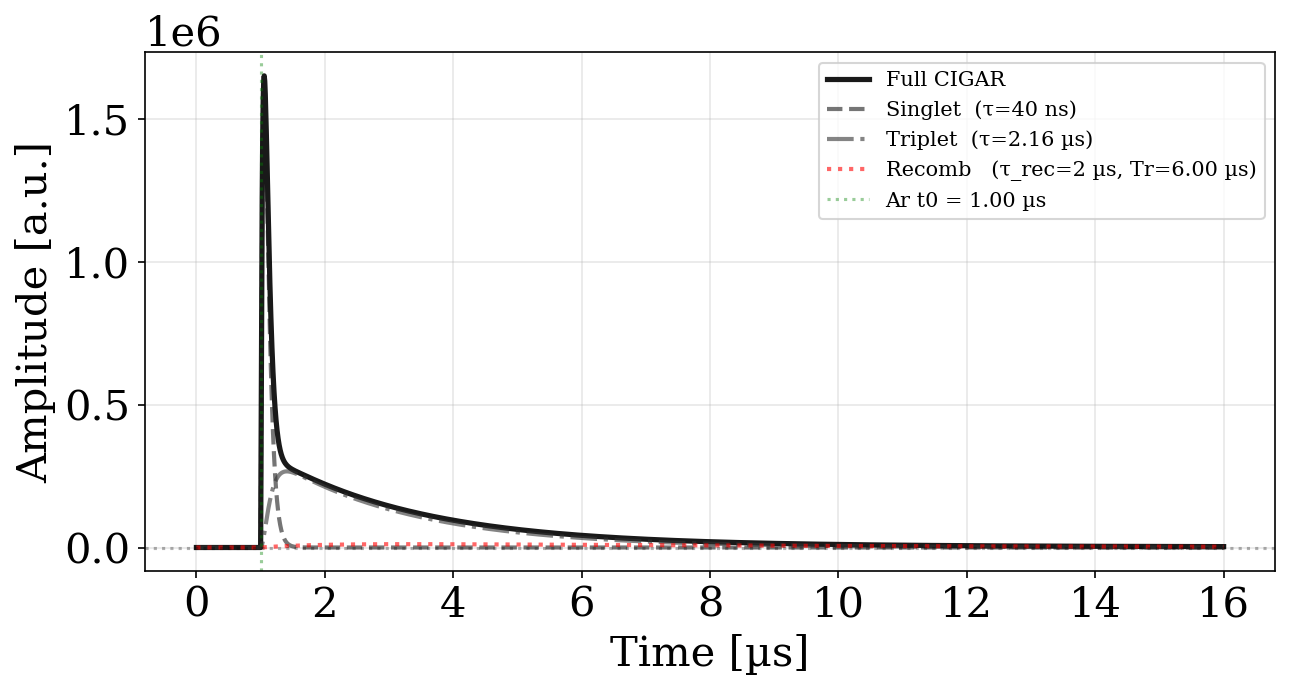

In [238]:
# =========================================================================== #
#  EXPLORER CELL -- edit dicts and re-run                                      #
# =========================================================================== #
time  = np.linspace(0, 16e-6, 2000)
t0 = time[125]

sipm_rise  = 1e-9
sipm_decay = 64e-9

A_tot     = 1
rec_factor = .1
singlet_p = dict(A=A_tot*(1-rec_factor)/4, rise=2e-9,   tau=40e-9)
triplet_p = dict(A=A_tot*(1-rec_factor)*3/4, rise=100e-9, tau=2.16e-6)
rec_p     = dict(A=A_tot*rec_factor, tau_rec=2.16e-6, Tr=6e-6)

u    = time - t0
mask = u > 0


h_singlet       = np.zeros_like(time)
h_singlet[mask] = _conv_two_rise_decay(u[mask], singlet_p["rise"], singlet_p["tau"], sipm_rise, sipm_decay)
area = np.trapz(h_singlet, x=time)
if area > 0: h_singlet *= singlet_p["A"] / area

h_triplet       = np.zeros_like(time)
h_triplet[mask] = _conv_two_rise_decay(u[mask], triplet_p["rise"], triplet_p["tau"], sipm_rise, sipm_decay)
area = np.trapz(h_triplet, x=time)
if area > 0: h_triplet *= triplet_p["A"] / area

h_rec = rec_p["A"] * recombination_model(time, t0, rec_p["tau_rec"], rec_p["Tr"])
area = np.trapz(h_rec, x=time)
if area > 0: h_rec *= rec_p["A"] / area

full  = h_singlet + h_triplet + h_rec

# pre-compute label values to avoid nested quotes in f-strings
tau_s_ns   = singlet_p["tau"] * 1e9
tau_t_us   = triplet_p["tau"] * 1e6
tau_rec_us = rec_p["tau_rec"] * 1e6
Tr_us      = rec_p["Tr"] * 1e6
t0_us      = t0 * 1e6

fig, ax = plt.subplots(figsize=(9, 5), dpi=150)

ax.plot(time*1e6, full,      color="k",    lw=2.5, alpha=0.9, label="Full CIGAR")

ax.plot(time*1e6, h_singlet, color=colors[1], lw=2, ls="--", alpha = 0.6,
        label=f"Singlet  (τ={tau_s_ns:.0f} ns)")

ax.plot(time*1e6, h_triplet, color=colors[2], lw=2, ls="-.", alpha = 0.6,
        label=f"Triplet  (τ={tau_t_us:.2f} µs)")

ax.plot(time*1e6, h_rec,     color='red', lw=2, ls=":", alpha = 0.6,
        label=f"Recomb   (τ_rec={tau_rec_us:.0f} µs, Tr={Tr_us:.2f} µs)")

ax.axvline(t0_us,    color="green",    ls=":", alpha=0.4, label=f"Ar t0 = {t0_us:.2f} µs")
ax.axhline(0, color="k", ls=":", alpha=0.3)

ax.set_xlabel("Time [µs]")
ax.set_ylabel("Amplitude [a.u.]")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
# ax.set_yscale('log')
plt.tight_layout()
# plt.show()

check_timescale_validity(singlet_p["tau"], triplet_p["tau"], rec_p["Tr"])


##  Signal time constants

In [239]:
run = {
    8.5: f"Run{171}"
  # 7.5: f"Run{173}"
  # 6.5: f"Run{175}"
  # 5.5: f"Run{177}"
  # 4.5: f"Run{179}"
  # 3.5: f"Run{181}"
  # 2.5: f"Run{183}"
  # 1.5: f"Run{185}"
}



--- CH1 @ 8.5 bar  [fit result] ---
Parameter                   Lower        Initial          Upper  In bounds?          Fitted   Clip-lo%  Clip-hi%
------------------------------------------------------------------------------------------------------------------------------
t0                     9.2800e-07 1.0080e-06     1.0880e-06           ✓      9.7874e-07     31.71%    68.29%
A_singlet              9.1997e-07 4.5998e-06     1.2880e-05           ✓      3.7032e-06     23.27%    76.73%
tau_singlet            2.5000e-08 3.9000e-08     8.0000e-08           ✓      6.8804e-08     79.64%    20.36%
A_triplet              0.0000e+00 1.3800e-05     1.7479e-05           ✓      1.7479e-05    100.00%    0.00% ⚠
rise_triplet           3.0000e-08 1.5000e-07     3.0000e-07           ✓      2.0567e-07     65.06%    34.94%
tau_triplet            1.2000e-06 2.1600e-06     2.8000e-06           ✓      2.3741e-06     73.38%    26.62%
A_rec                  4.2731e-06 2.1366e-05     3.3800e-05         

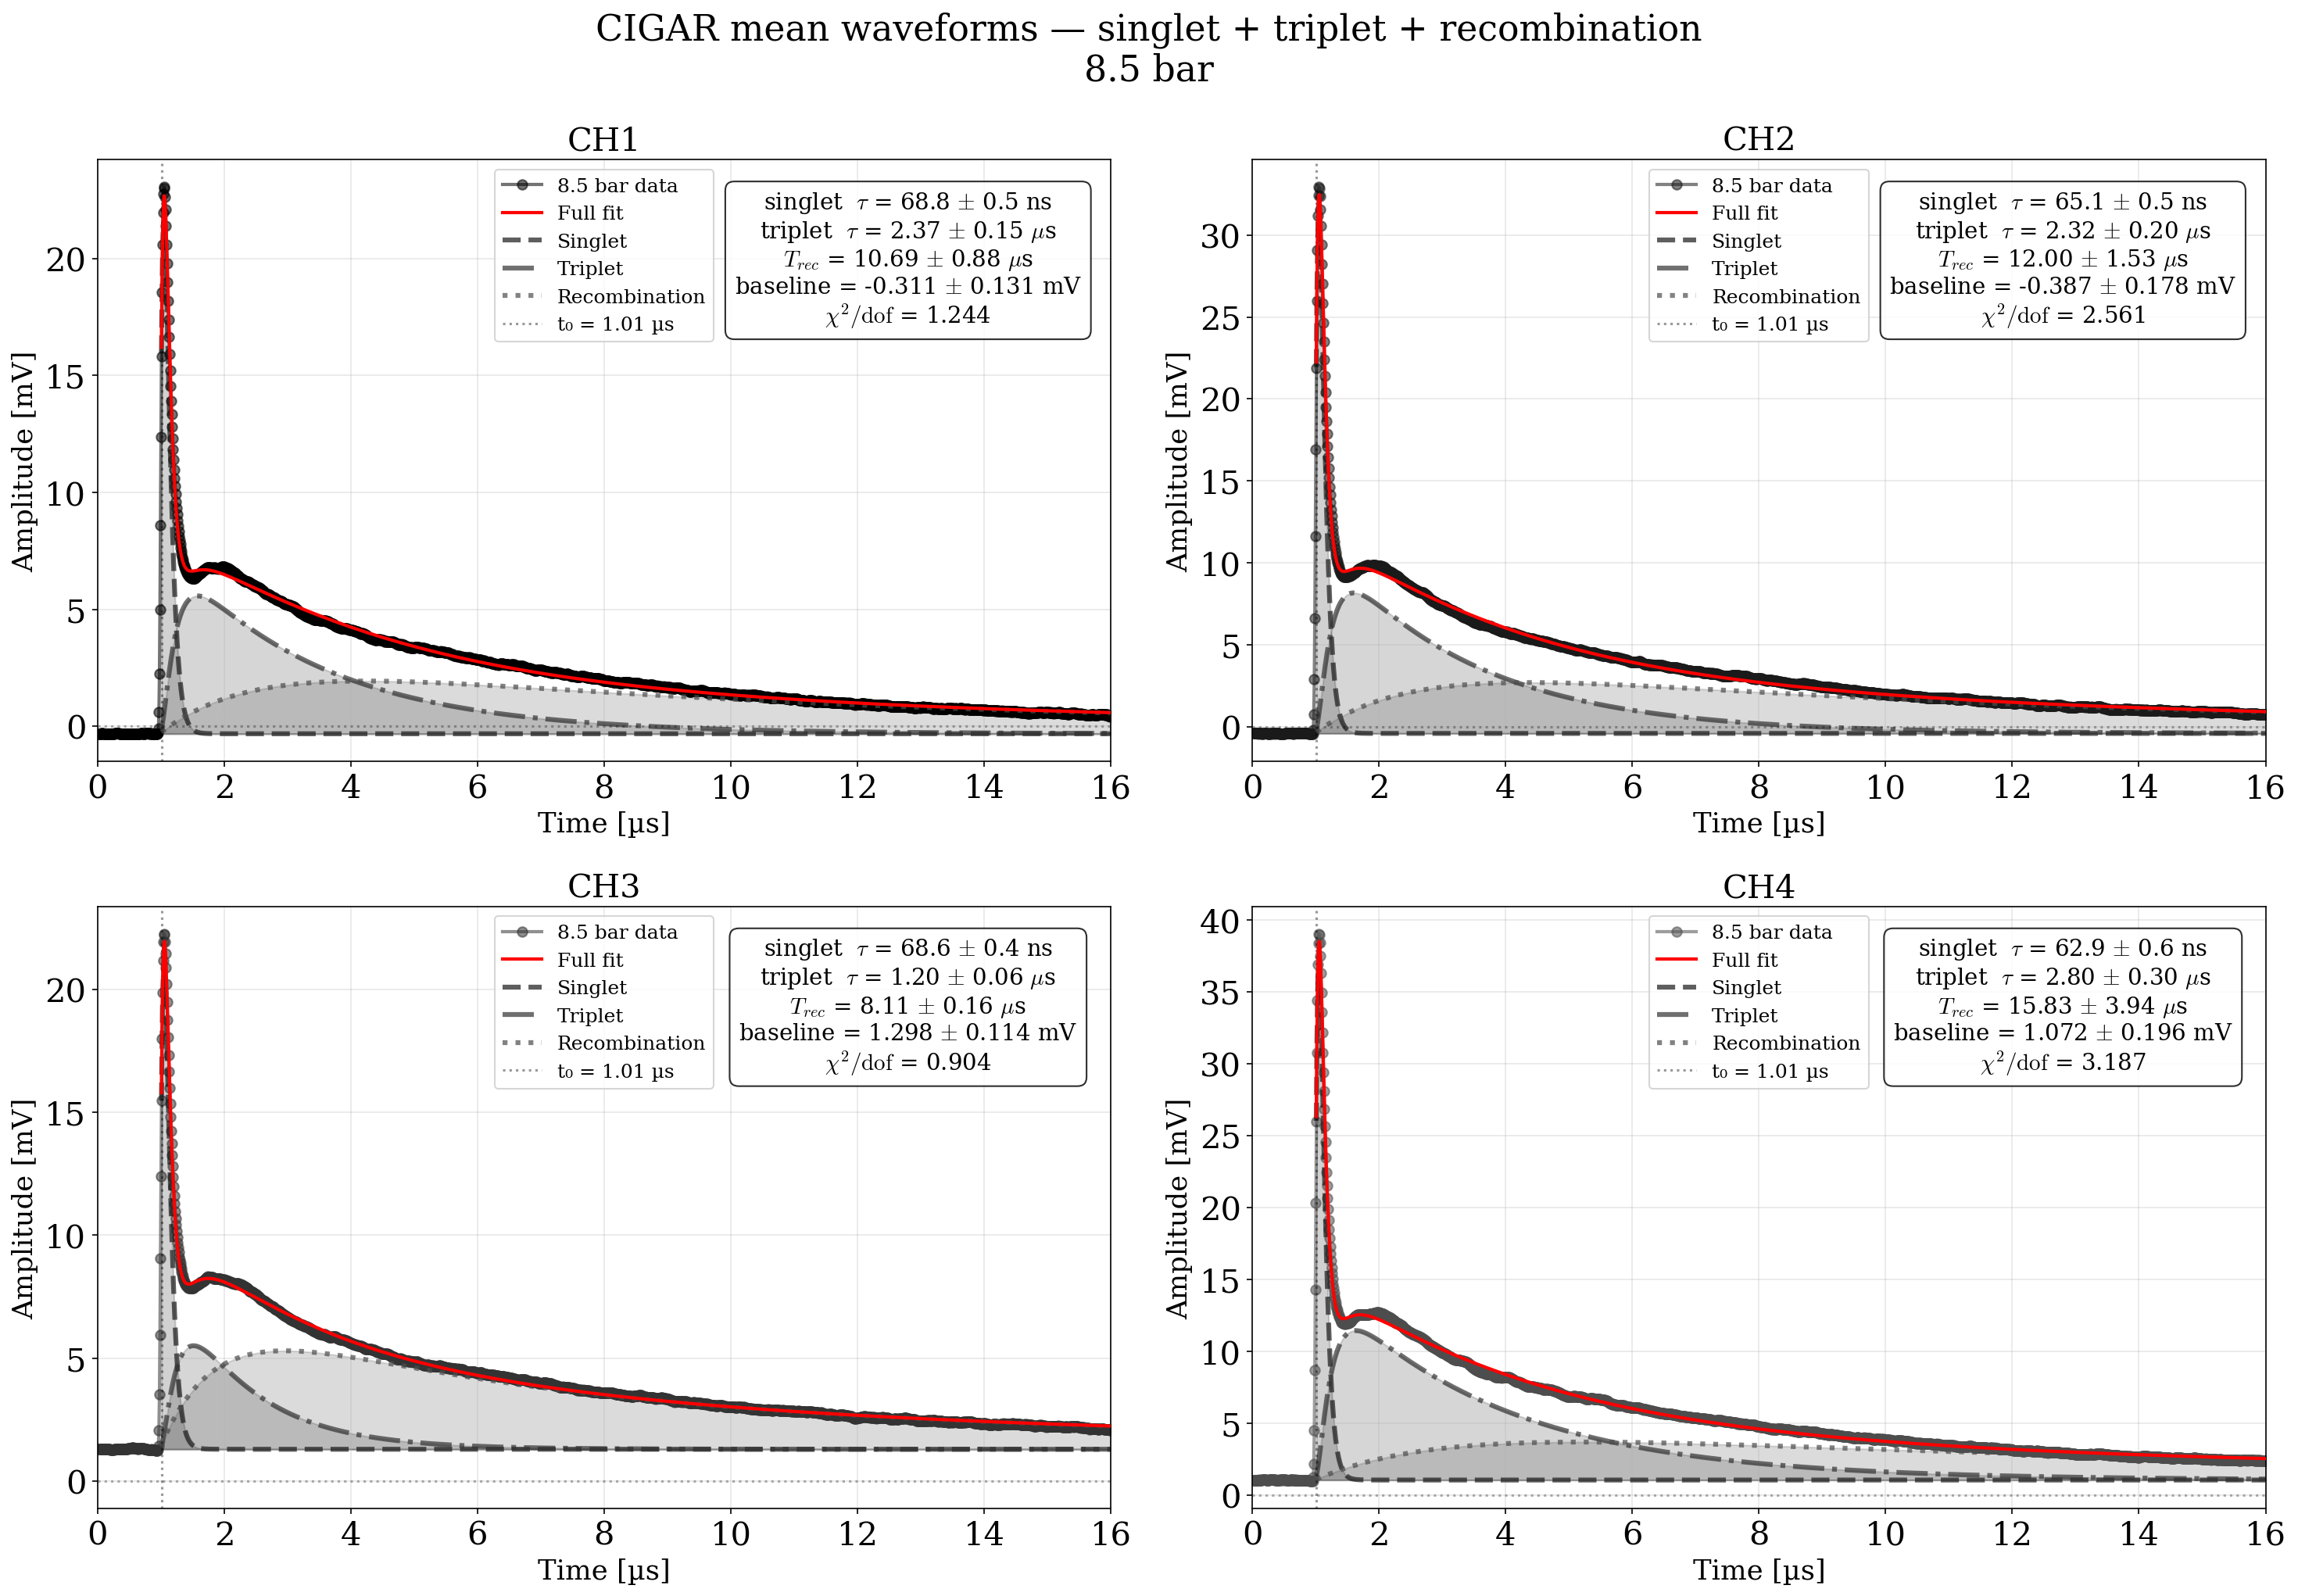

In [240]:
fig_cig, axs, cigar_params = fit_cigar_waveforms(run, base, pretrigger_sample=pretrigger,
                                                 channels_to_show=None, invert=True,
                                                 p0_cigar=None, bounds_cigar=None,
                                                 colors=colors, font_size=20, logscale=False)


for ch, p in cigar_params.items():
    print(f"\n=== {ch} ===")
    check_timescale_validity(p["tau_singlet"], p["tau_triplet"], p["Tr"])

# for ax in axs.flatten():
#     ax.set_ylim(-1, 50)
#     ax.set_xlim(.9, 1.3)
# plt.show()

In [241]:
cigar_params['CH2']

{'t0': 9.81282607156398e-07,
 'A_singlet': 5.203739370896777e-06,
 'rise_singlet': 1e-09,
 'tau_singlet': 6.5117981477552e-08,
 'A_triplet': 2.5196164756132515e-05,
 'rise_triplet': 2.202876052504178e-07,
 'tau_triplet': 2.323988996301607e-06,
 'A_rec': 3.282133657288628e-05,
 'tau_rec': 2.323988996301607e-06,
 'Tr': 1.1996391662313503e-05,
 'baseline': -0.3874098699060656,
 'pcov': array([[ 7.73289313e-20, -1.99196640e-18, -1.07362328e-19,
         -1.68489792e-16, -5.09996165e-19, -1.22645240e-17,
          1.70352681e-16, -9.90176207e-17],
        [-1.99196640e-18,  2.88065403e-16,  5.81185140e-18,
          3.03824215e-14,  5.61478079e-17,  2.22064595e-15,
         -3.06335365e-14,  1.75625883e-14],
        [-1.07362328e-19,  5.81185140e-18,  2.12723061e-19,
          5.13057385e-16,  1.32884793e-18,  3.73672860e-17,
         -5.18598610e-16,  3.00337912e-16],
        [-1.68489792e-16,  3.03824215e-14,  5.13057385e-16,
          7.35769347e-12,  5.97598109e-15,  5.42718120e-13,
   

In [242]:
runs = {
    8.5: f"Run{171}",
    7.5: f"Run{173}",
    6.5: f"Run{175}",
    5.5: f"Run{177}",
    4.5: f"Run{179}",
    3.5: f"Run{181}",
    2.5: f"Run{183}",
    1.5: f"Run{185}",
}


In [243]:
check_aprox_validity = False


--- CH1 @ 8.5 bar  [fit result] ---
Parameter                   Lower        Initial          Upper  In bounds?          Fitted   Clip-lo%  Clip-hi%
------------------------------------------------------------------------------------------------------------------------------
t0                     9.2800e-07 1.0080e-06     1.0880e-06           ✓      9.7874e-07     31.71%    68.29%
A_singlet              9.1997e-07 4.5998e-06     1.2880e-05           ✓      3.7032e-06     23.27%    76.73%
tau_singlet            2.5000e-08 3.9000e-08     8.0000e-08           ✓      6.8804e-08     79.64%    20.36%
A_triplet              0.0000e+00 1.3800e-05     1.7479e-05           ✓      1.7479e-05    100.00%    0.00% ⚠
rise_triplet           3.0000e-08 1.5000e-07     3.0000e-07           ✓      2.0567e-07     65.06%    34.94%
tau_triplet            1.2000e-06 2.1600e-06     2.8000e-06           ✓      2.3741e-06     73.38%    26.62%
A_rec                  4.2731e-06 2.1366e-05     3.3800e-05         

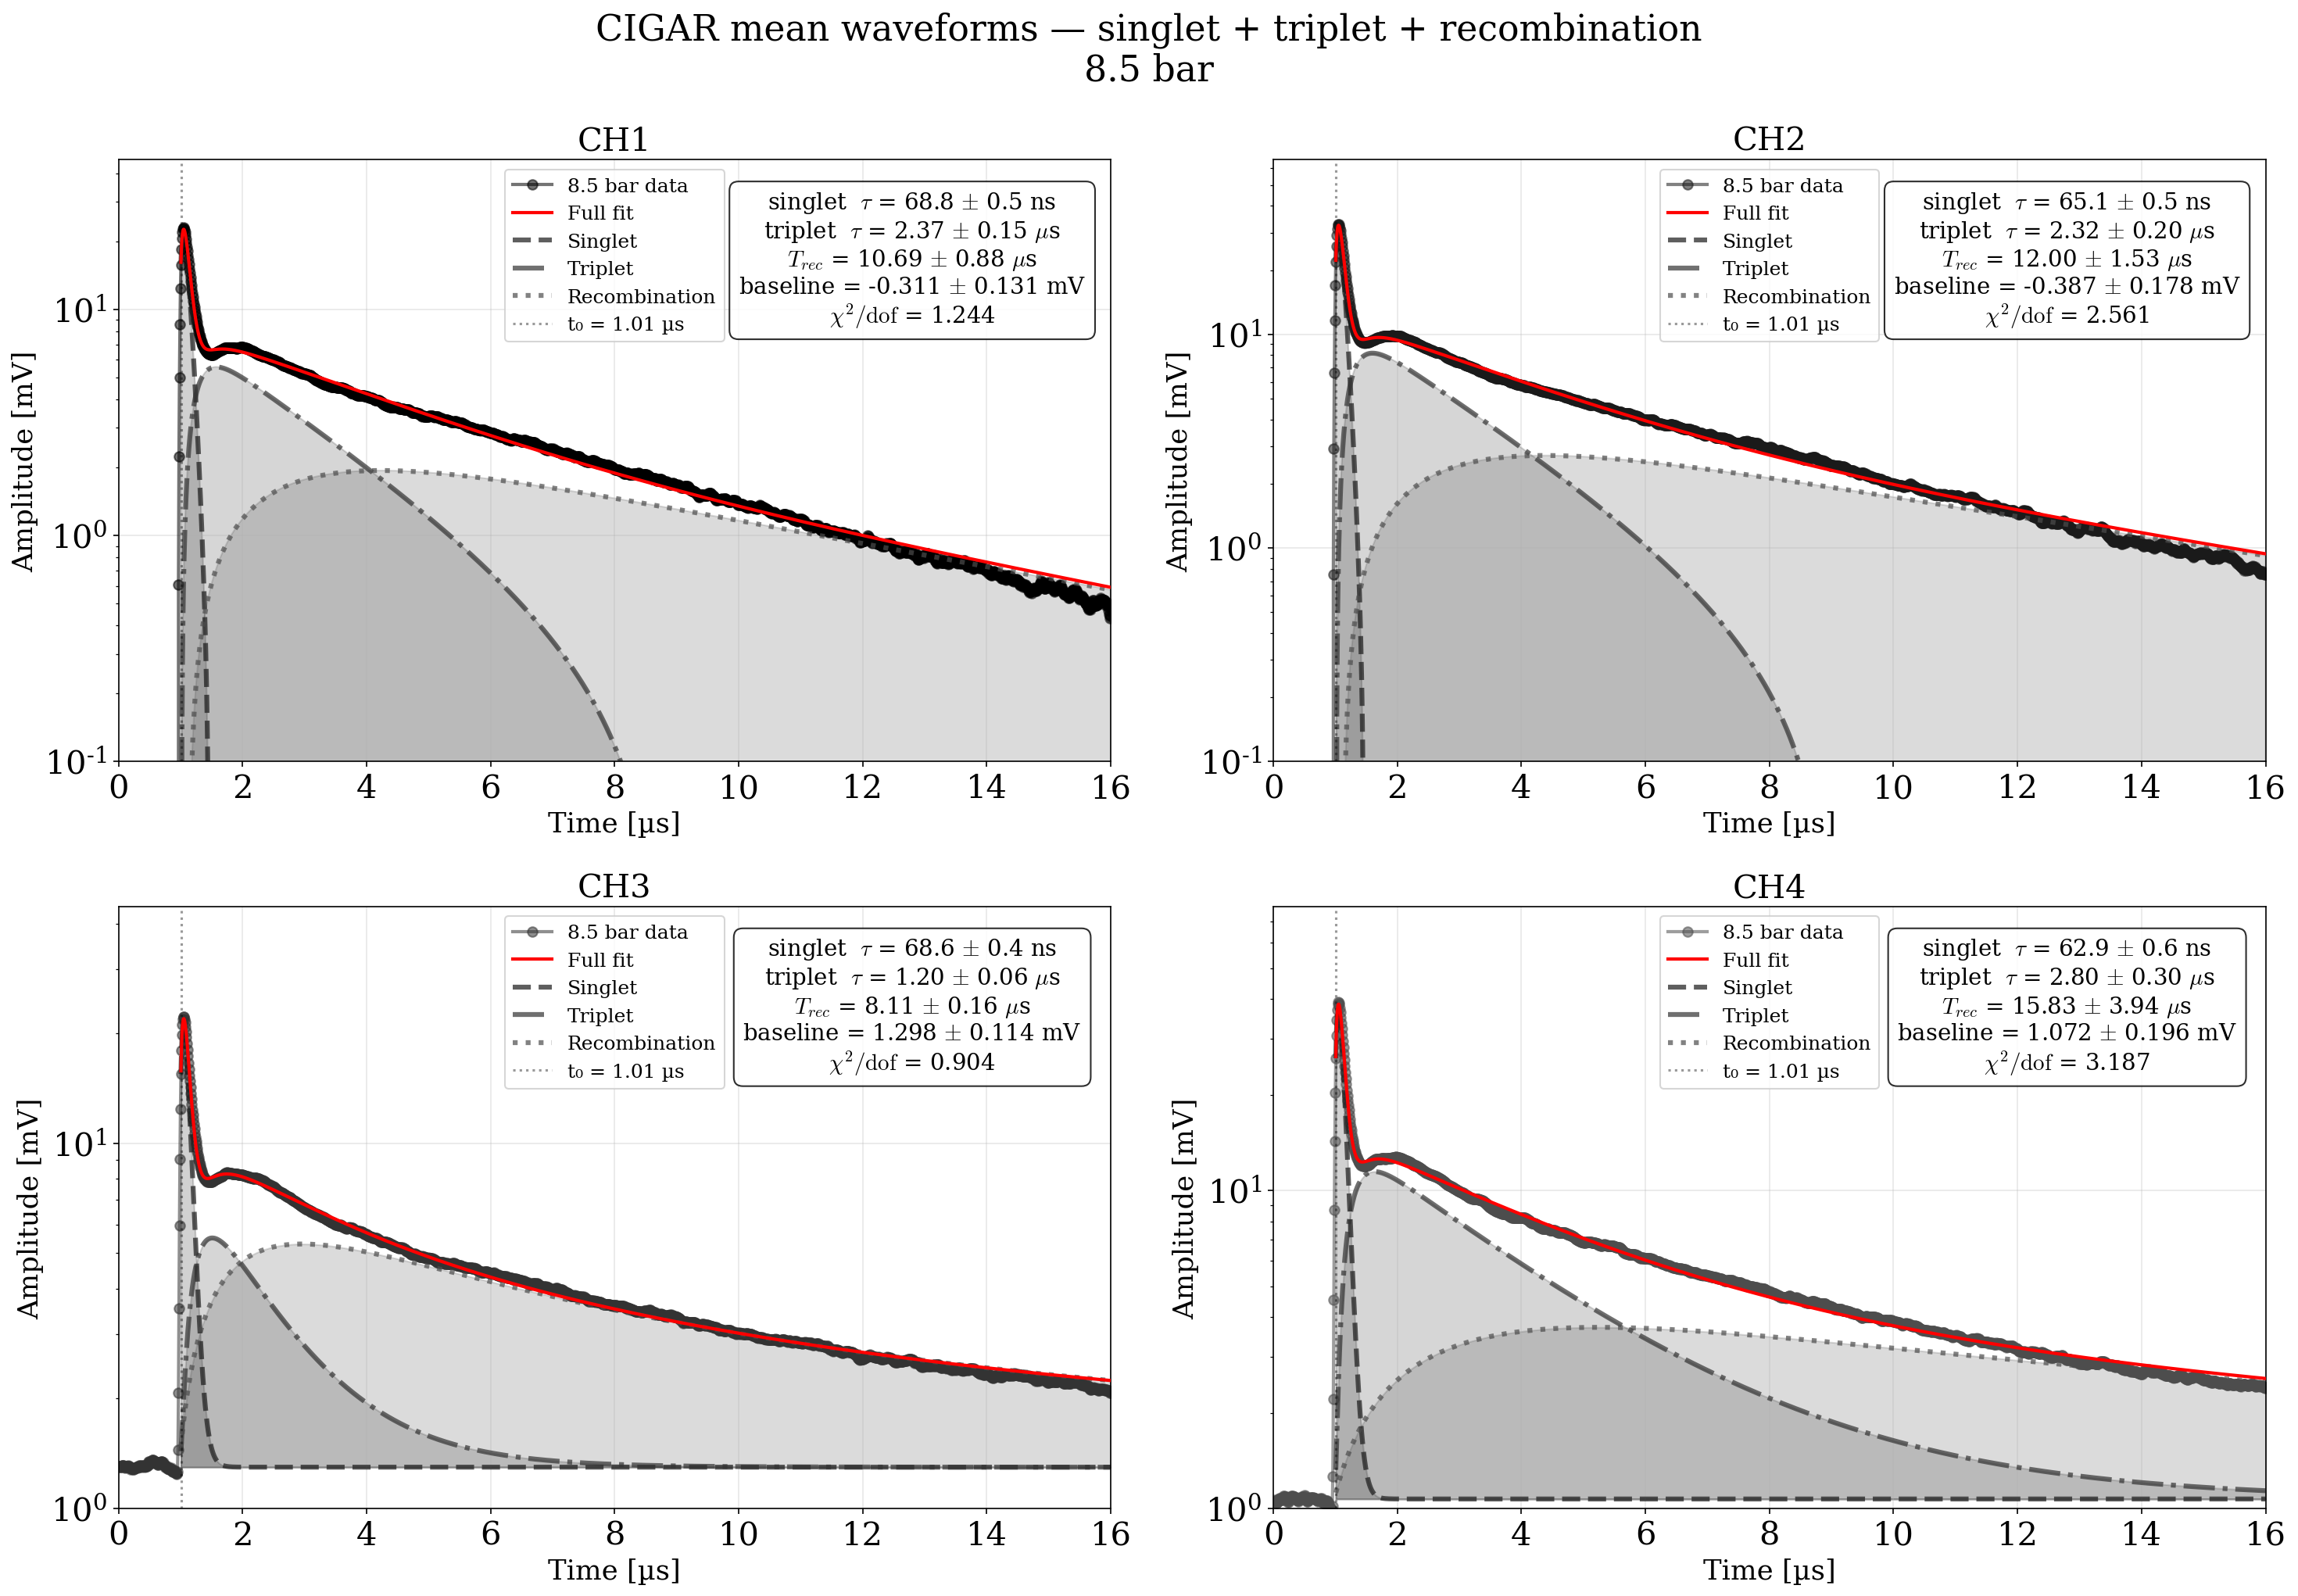


--- CH1 @ 7.5 bar  [fit result] ---
Parameter                   Lower        Initial          Upper  In bounds?          Fitted   Clip-lo%  Clip-hi%
------------------------------------------------------------------------------------------------------------------------------
t0                     9.2800e-07 1.0080e-06     1.0880e-06           ✓      9.7835e-07     31.47%    68.53%
A_singlet              8.9346e-07 4.4673e-06     1.2508e-05           ✓      3.8419e-06     25.38%    74.62%
tau_singlet            2.5000e-08 3.9000e-08     8.0000e-08           ✓      7.1505e-08     84.56%    15.44%
A_triplet              0.0000e+00 1.3402e-05     1.6976e-05           ✓      5.5150e-06     32.49%    67.51%
rise_triplet           3.0000e-08 1.5000e-07     3.0000e-07           ✓      1.7045e-07     52.02%    47.98%
tau_triplet            1.2000e-06 2.1600e-06     2.8000e-06           ✓      1.2004e-06     0.03% ⚠    99.97%
A_rec                  3.7955e-06 1.8977e-05     3.1320e-05         

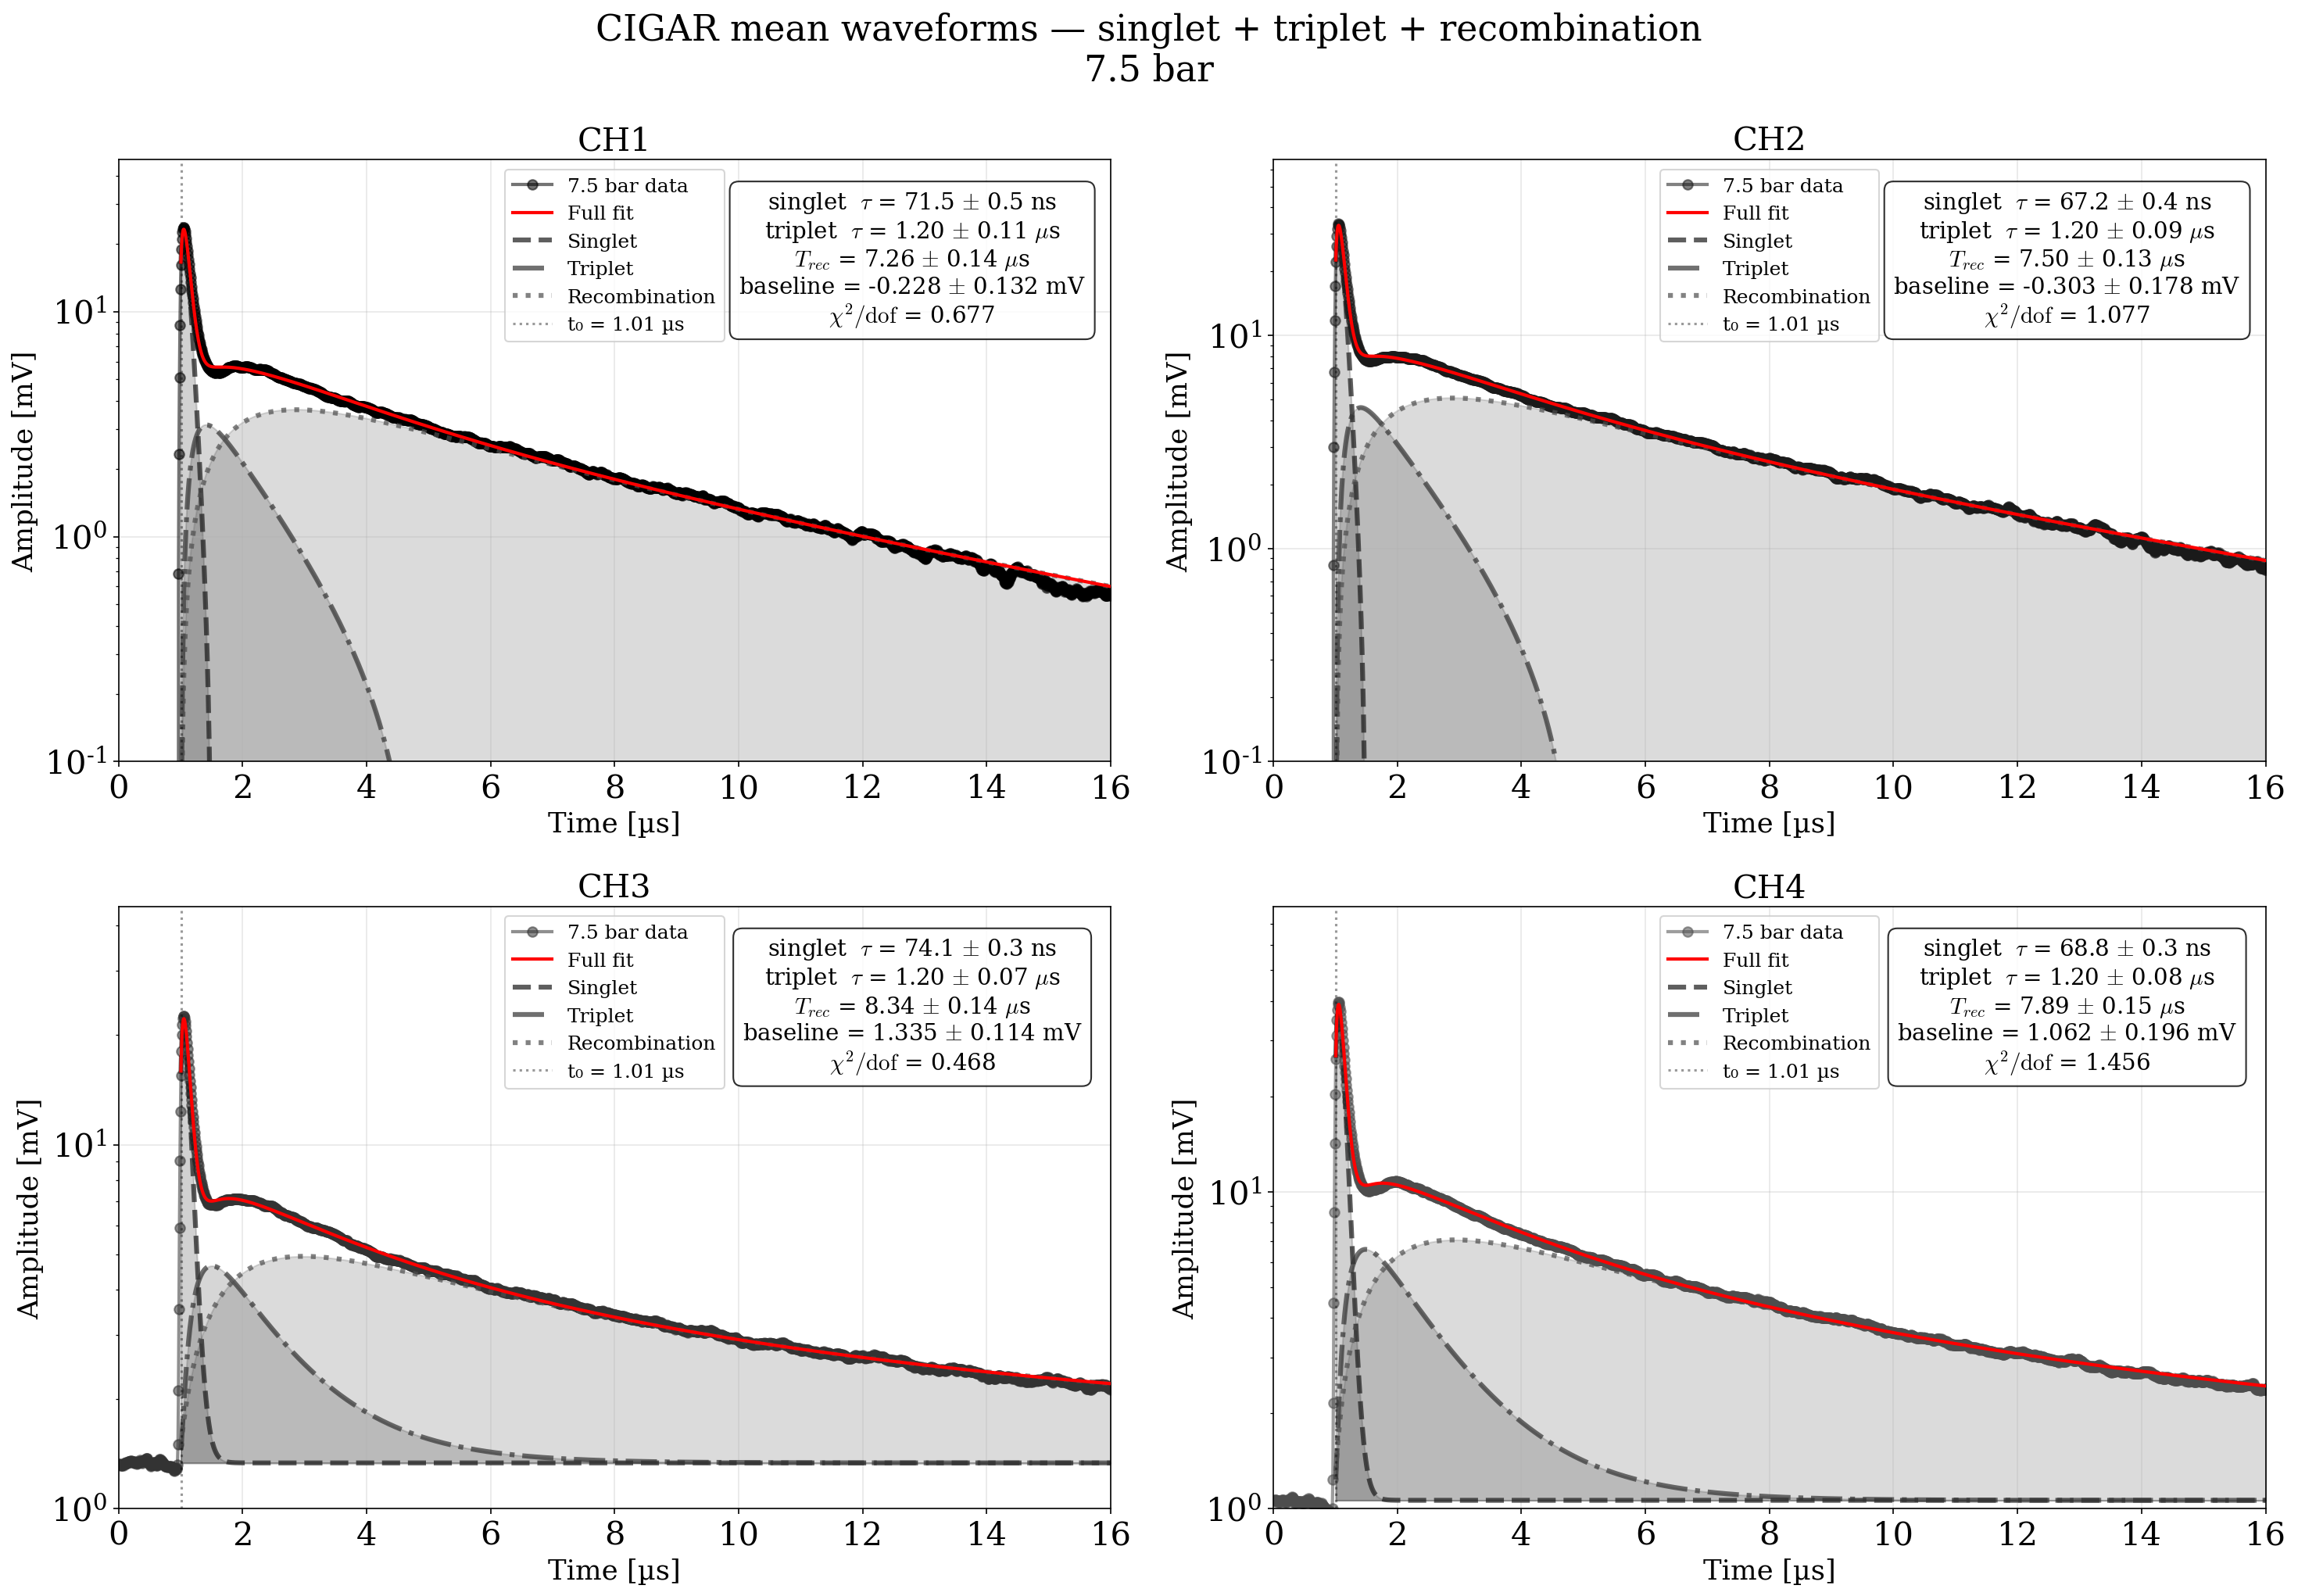


--- CH1 @ 6.5 bar  [fit result] ---
Parameter                   Lower        Initial          Upper  In bounds?          Fitted   Clip-lo%  Clip-hi%
------------------------------------------------------------------------------------------------------------------------------
t0                     9.2800e-07 1.0080e-06     1.0880e-06           ✓      9.7835e-07     31.47%    68.53%
A_singlet              1.0069e-06 5.0347e-06     1.4097e-05           ✓      4.0569e-06     23.30%    76.70%
tau_singlet            2.5000e-08 3.9000e-08     8.0000e-08           ✓      7.1885e-08     85.25%    14.75%
A_triplet              0.0000e+00 1.5104e-05     1.9132e-05           ✓      8.4134e-06     43.98%    56.02%
rise_triplet           3.0000e-08 1.5000e-07     3.0000e-07           ✓      6.3422e-08     12.38%    87.62%
tau_triplet            1.2000e-06 2.1600e-06     2.8000e-06           ✓      1.9312e-06     45.70%    54.30%
A_rec                  3.5706e-06 1.7853e-05     3.2293e-05          

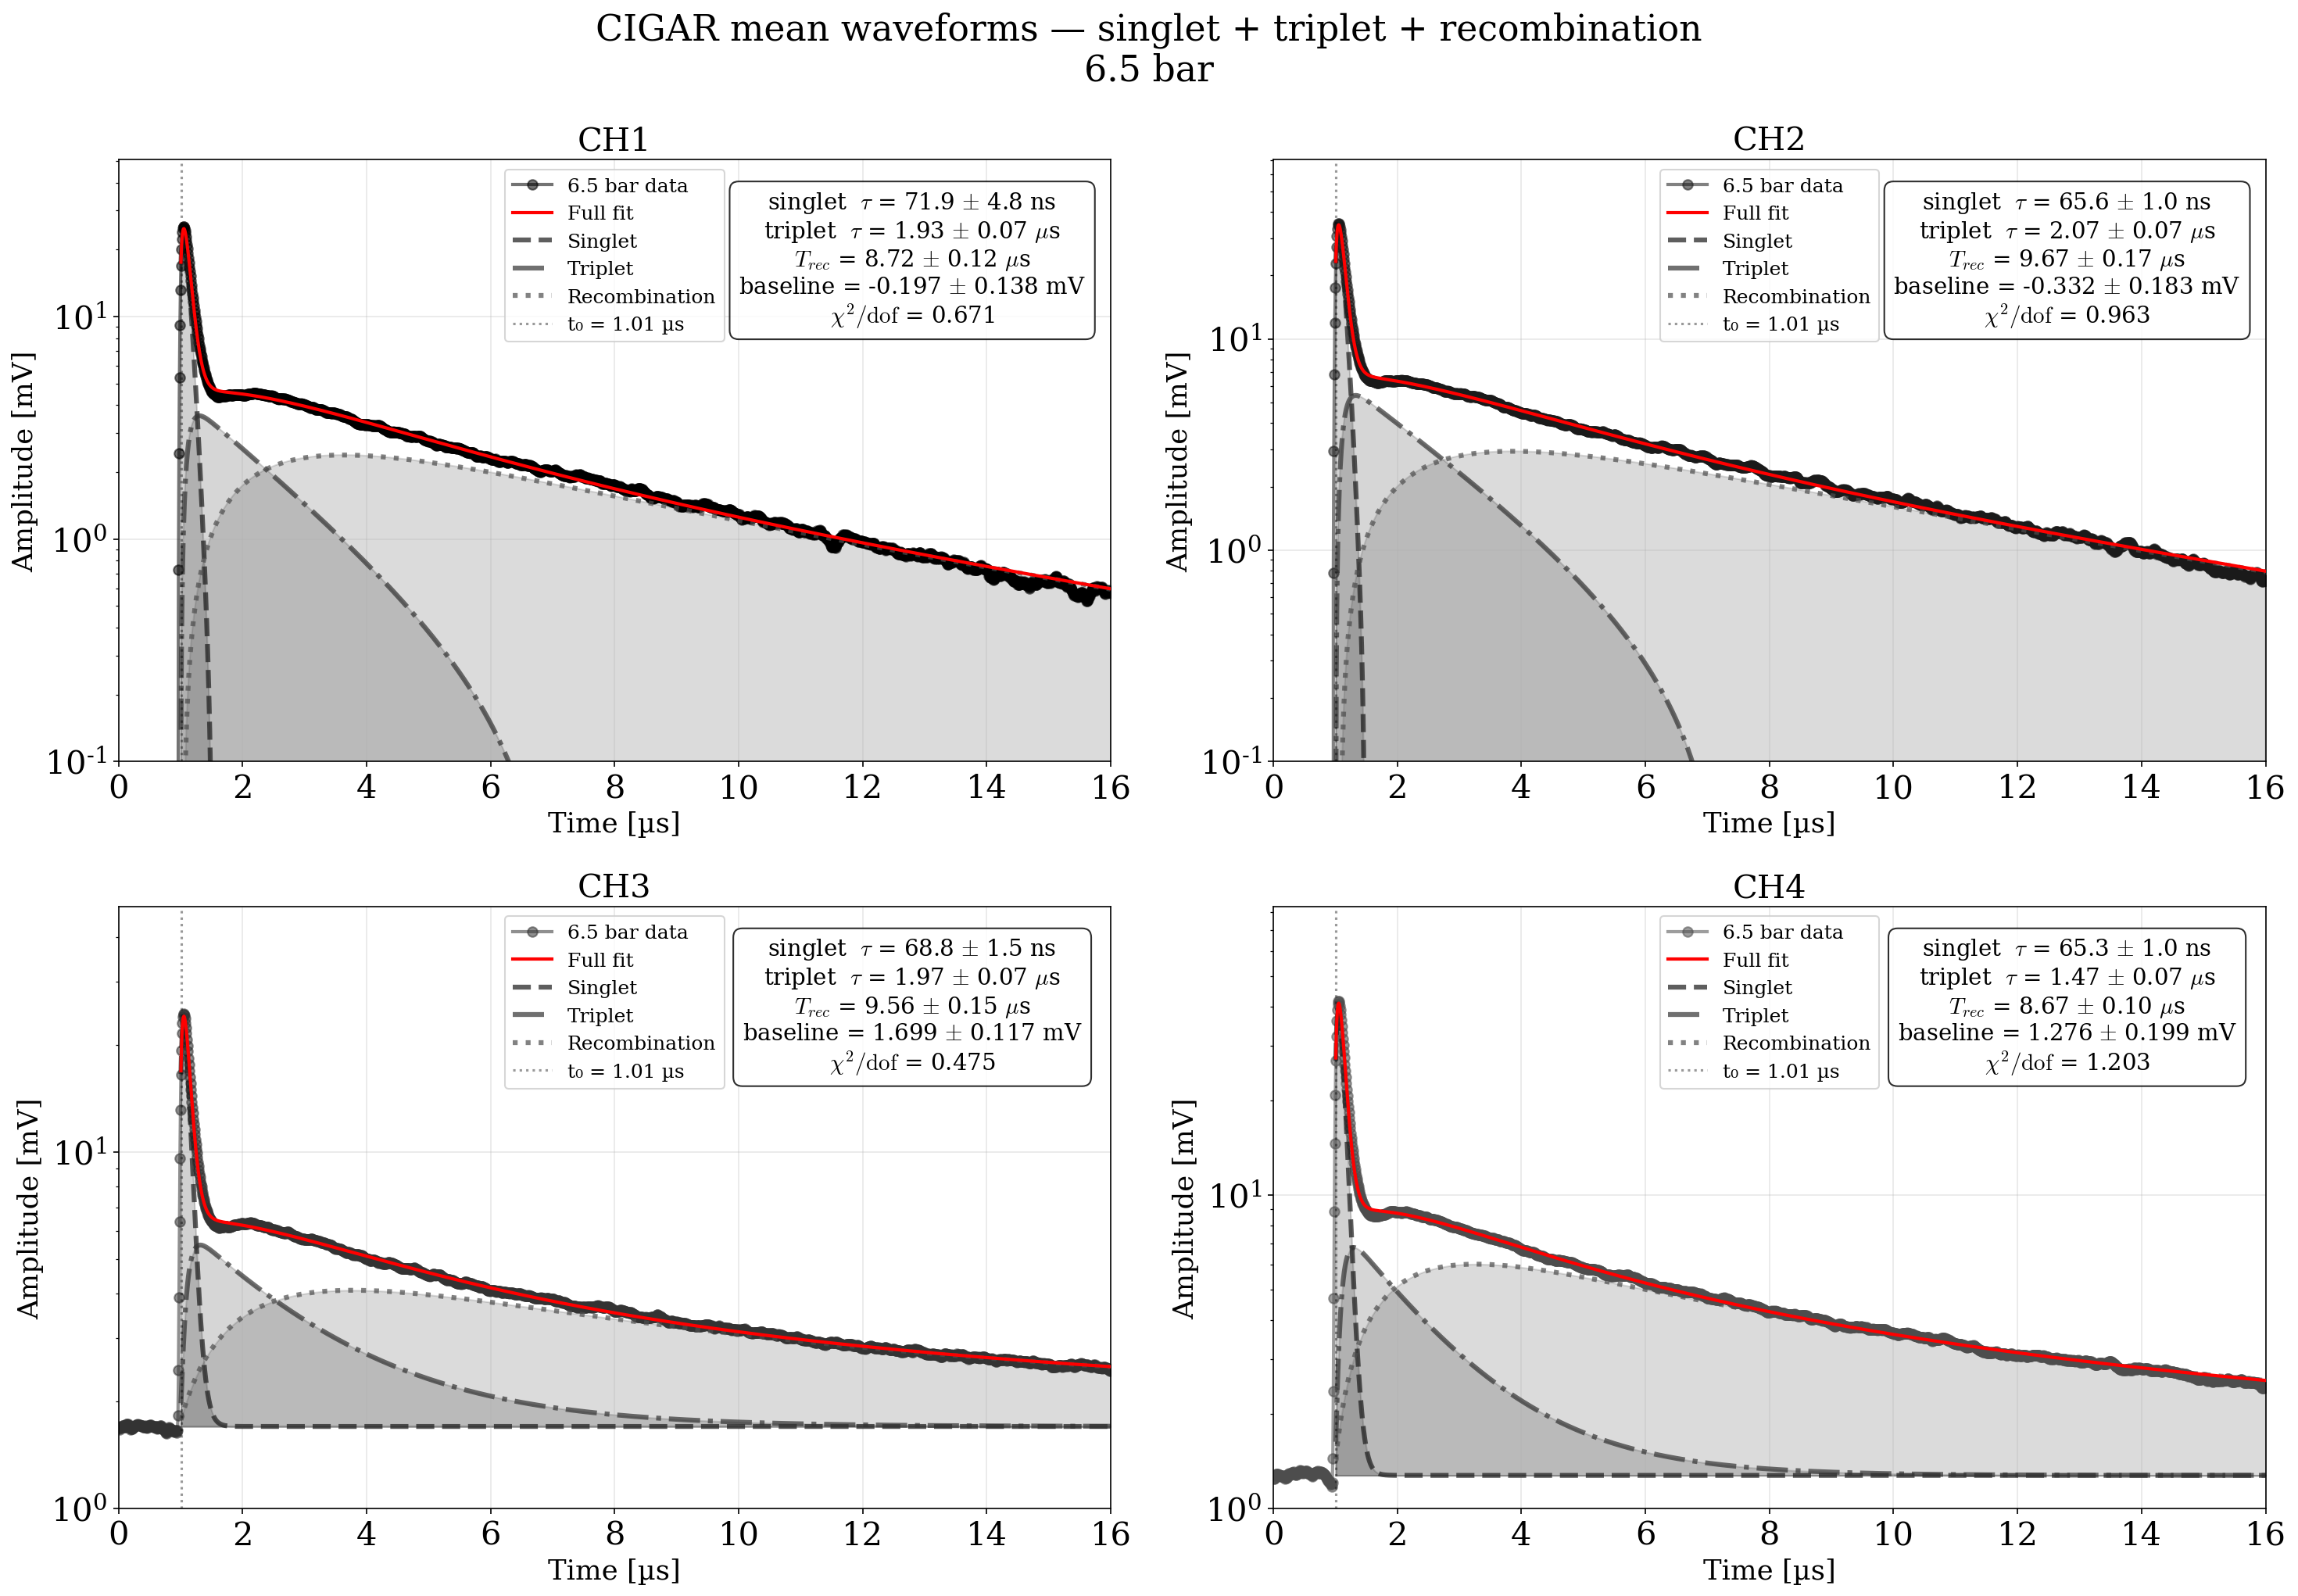


--- CH1 @ 5.5 bar  [fit result] ---
Parameter                   Lower        Initial          Upper  In bounds?          Fitted   Clip-lo%  Clip-hi%
------------------------------------------------------------------------------------------------------------------------------
t0                     9.2800e-07 1.0080e-06     1.0880e-06           ✓      9.7746e-07     30.91%    69.09%
A_singlet              1.2135e-06 6.0673e-06     1.6989e-05           ✓      4.5795e-06     21.34%    78.66%
tau_singlet            2.5000e-08 3.9000e-08     8.0000e-08           ✓      7.9993e-08     99.99%    0.01% ⚠
A_triplet              0.0000e+00 1.8202e-05     2.3056e-05           ✓      1.1115e-05     48.21%    51.79%
rise_triplet           3.0000e-08 1.5000e-07     3.0000e-07           ✓      6.5471e-08     13.14%    86.86%
tau_triplet            1.2000e-06 2.1600e-06     2.8000e-06           ✓      2.7999e-06     99.99%    0.01% ⚠
A_rec                  3.1743e-06 1.5872e-05     3.4120e-05        

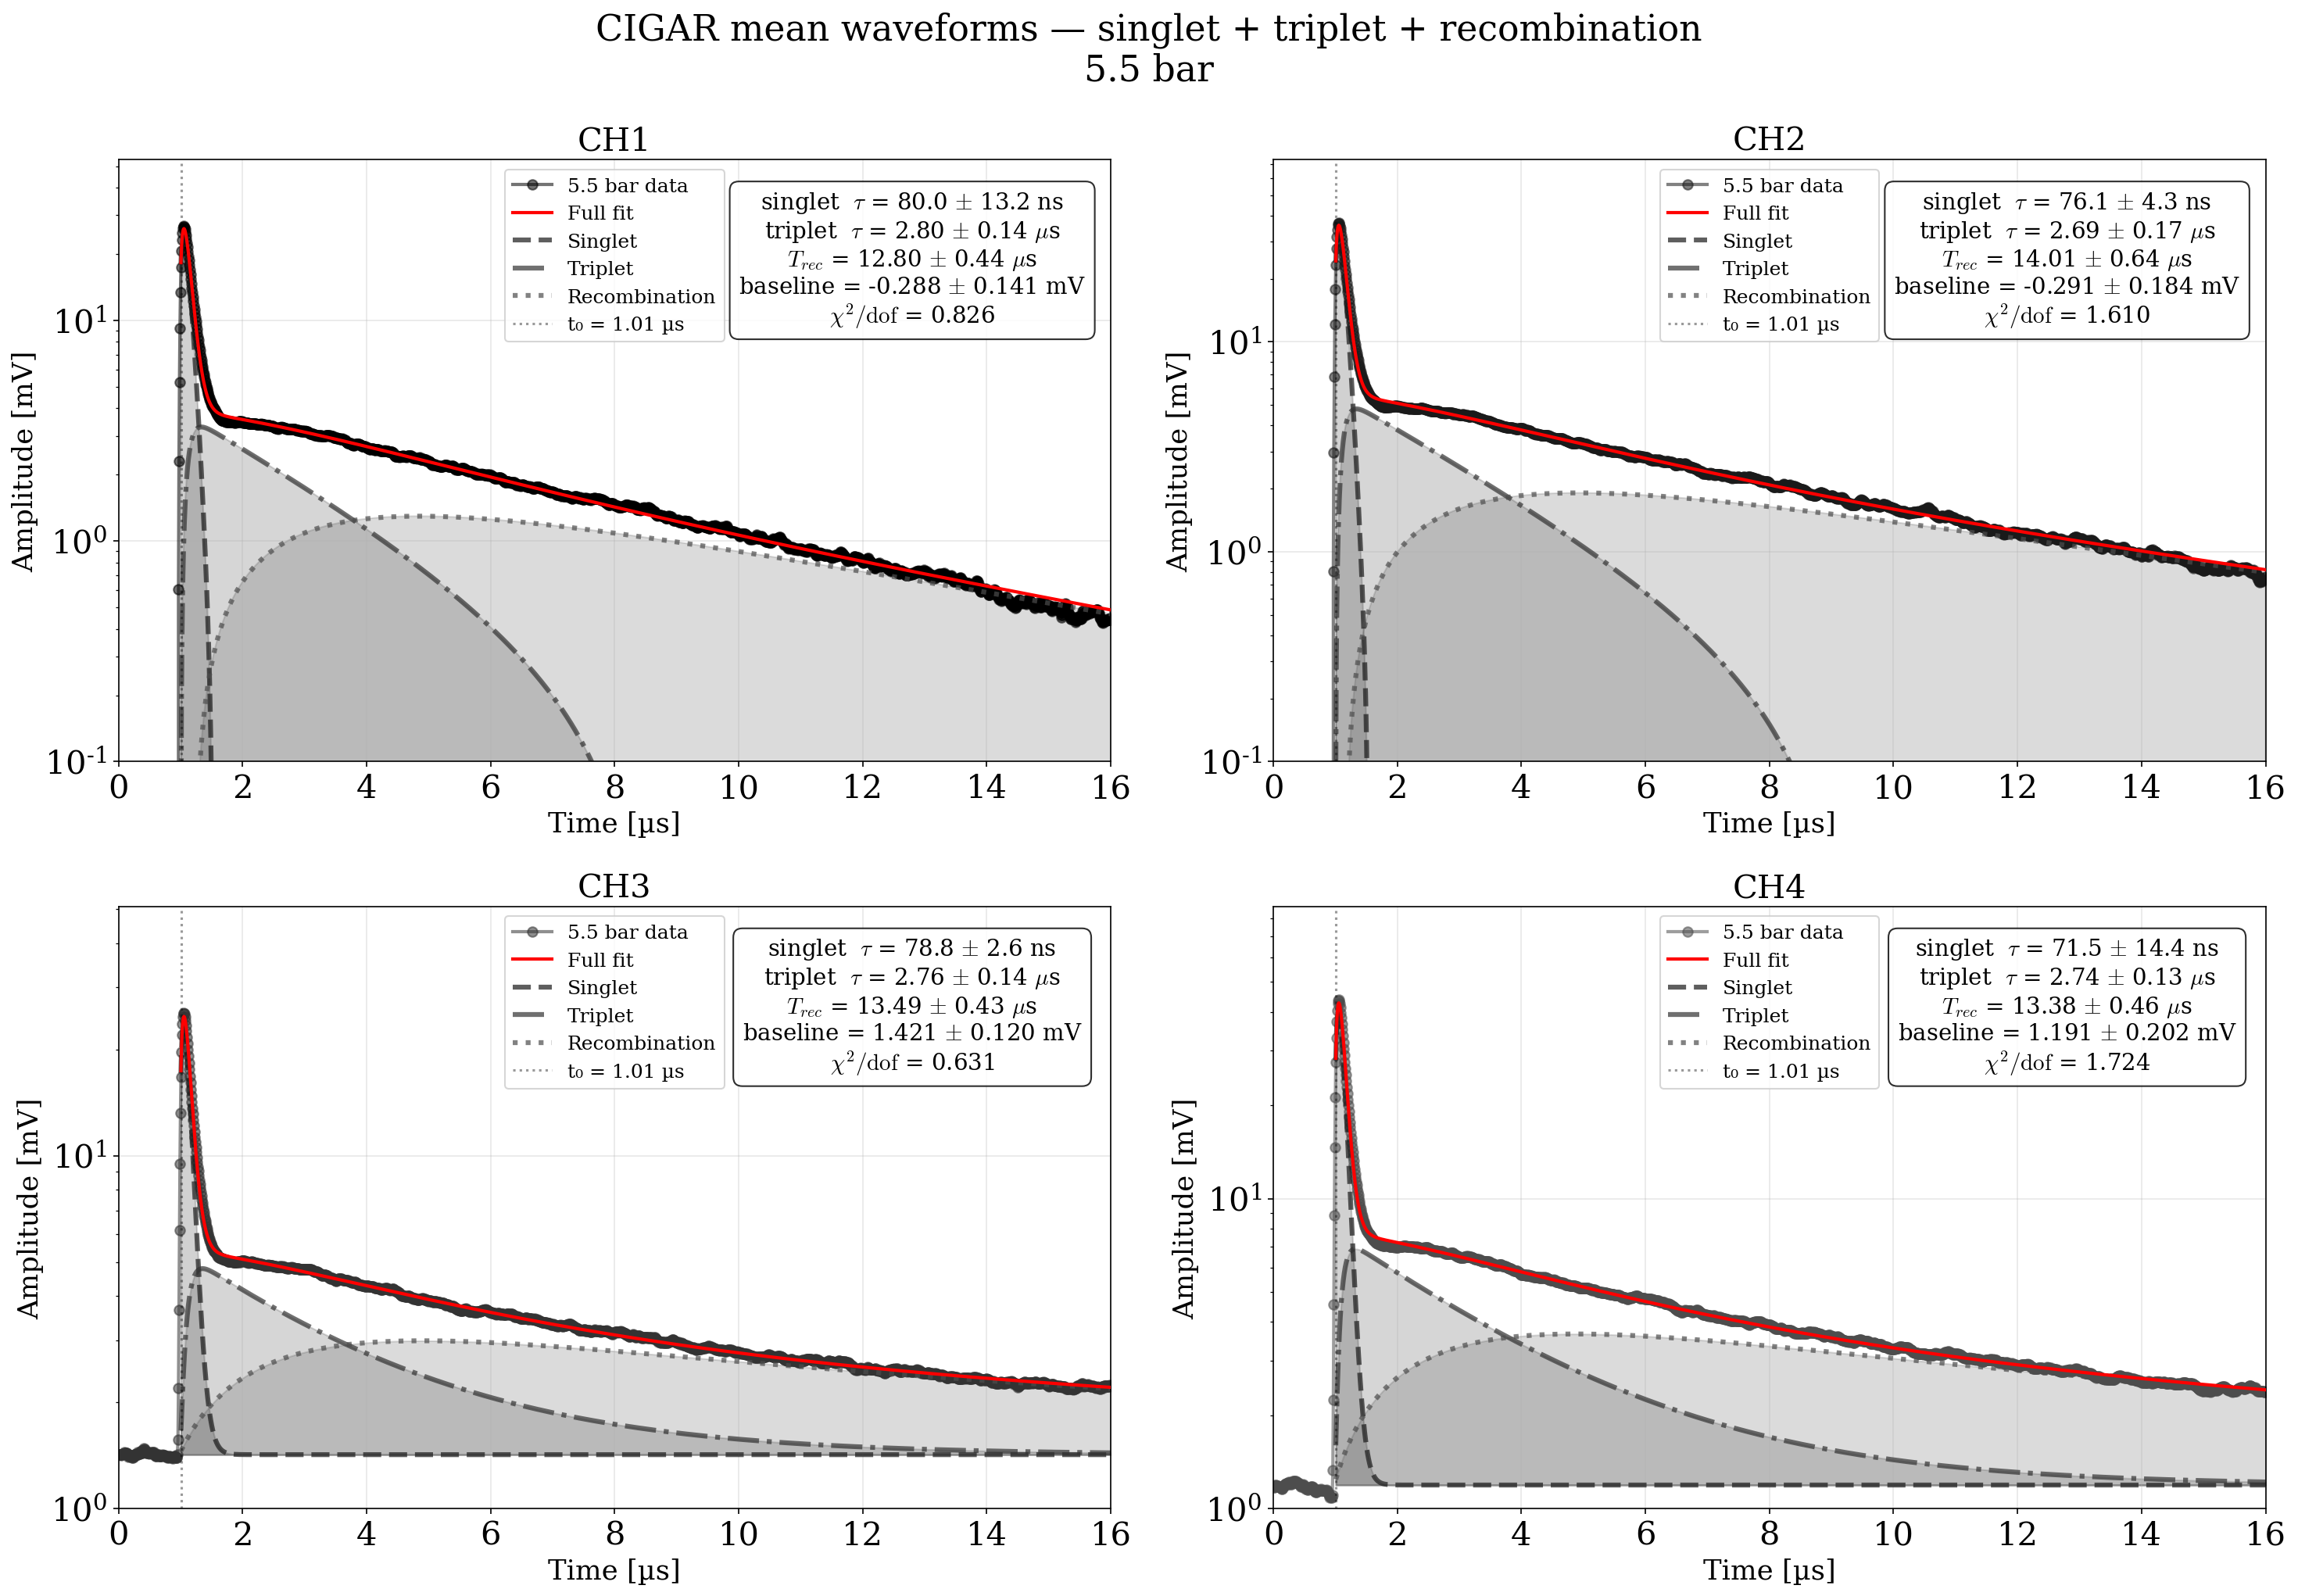


--- CH1 @ 4.5 bar  [fit result] ---
Parameter                   Lower        Initial          Upper  In bounds?          Fitted   Clip-lo%  Clip-hi%
------------------------------------------------------------------------------------------------------------------------------
t0                     9.2800e-07 1.0080e-06     1.0880e-06           ✓      9.8059e-07     32.87%    67.13%
A_singlet              1.4926e-06 7.4631e-06     2.0897e-05           ✓      4.9137e-06     17.63%    82.37%
tau_singlet            2.5000e-08 3.9000e-08     8.0000e-08           ✓      8.0000e-08    100.00%    0.00% ⚠
A_triplet              0.0000e+00 2.2389e-05     2.8360e-05           ✓      9.5580e-06     33.70%    66.30%
rise_triplet           3.0000e-08 1.5000e-07     3.0000e-07           ✓      4.8864e-08      6.99%    93.01%
tau_triplet            1.2000e-06 2.1600e-06     2.8000e-06           ✓      2.5488e-06     84.30%    15.70%
A_rec                  2.4976e-06 1.2488e-05     3.5990e-05         

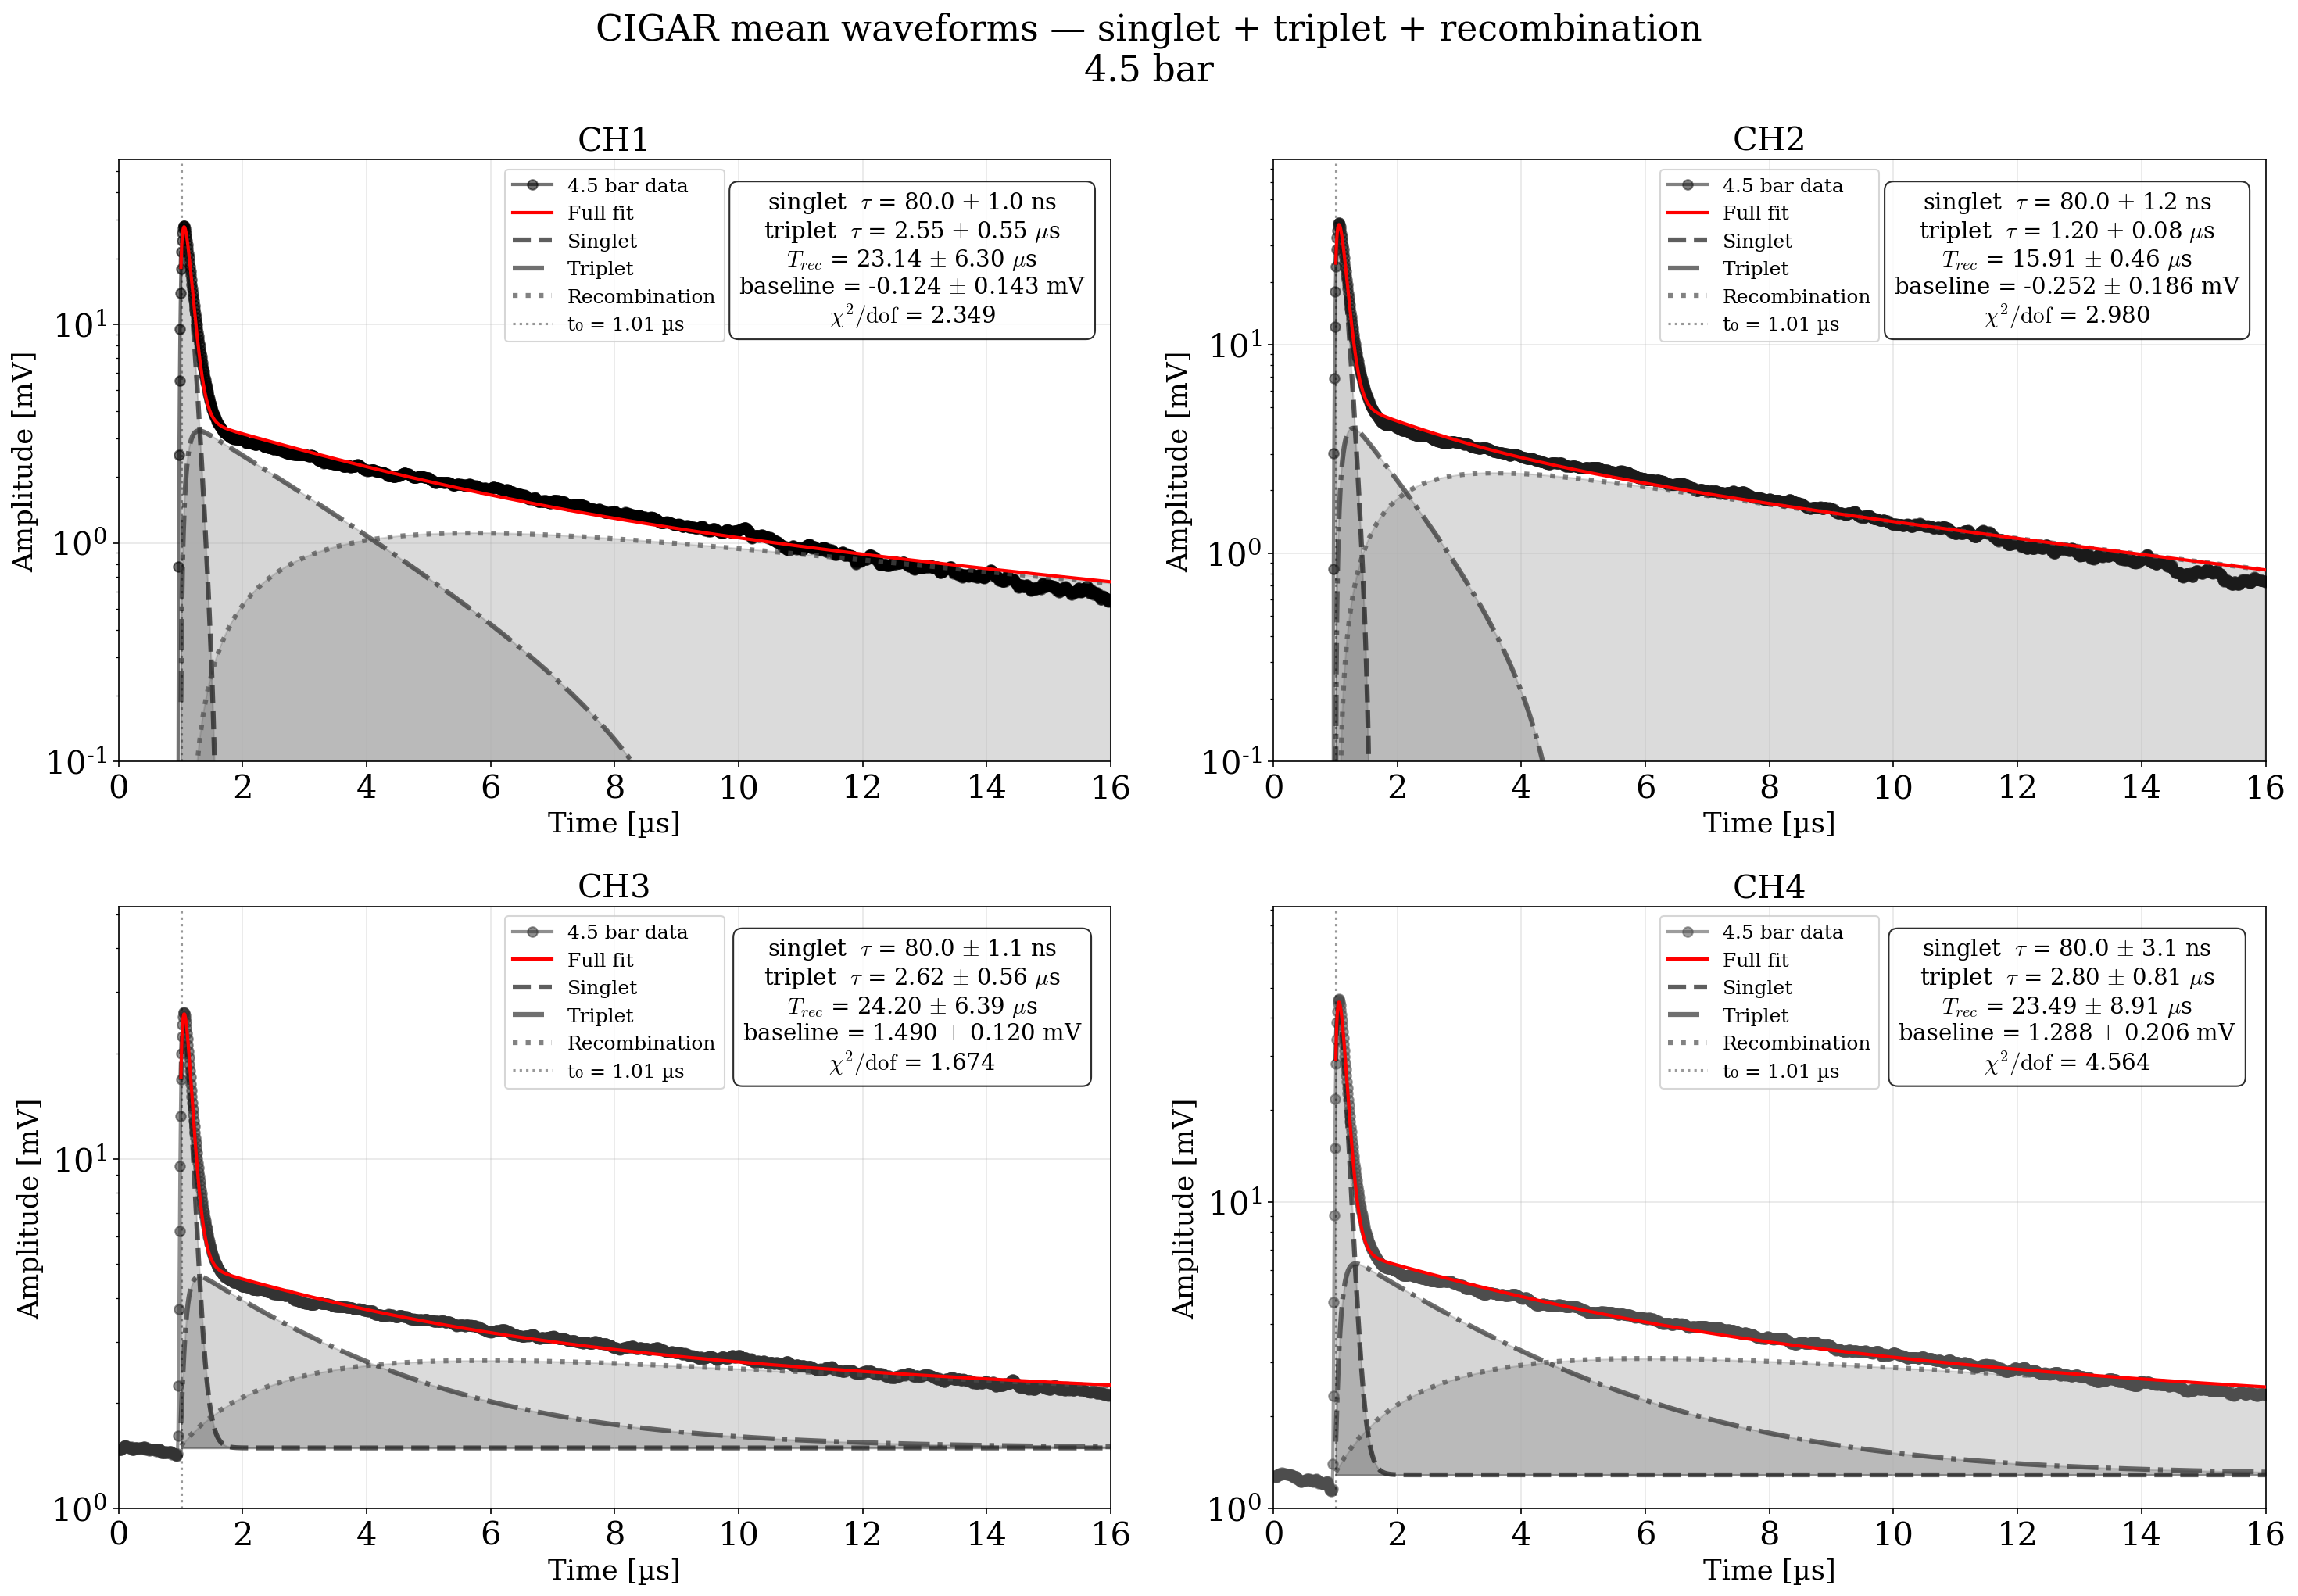


--- CH1 @ 3.5 bar  [fit result] ---
Parameter                   Lower        Initial          Upper  In bounds?          Fitted   Clip-lo%  Clip-hi%
------------------------------------------------------------------------------------------------------------------------------
t0                     9.2800e-07 1.0080e-06     1.0880e-06           ✓      9.8222e-07     33.89%    66.11%
A_singlet              1.8224e-06 9.1121e-06     2.5514e-05           ✓      5.1800e-06     14.17%    85.83%
tau_singlet            2.5000e-08 3.9000e-08     8.0000e-08           ✓      7.9999e-08    100.00%    0.00% ⚠
A_triplet              0.0000e+00 2.7336e-05     3.4626e-05           ✓      6.0480e-06     17.47%    82.53%
rise_triplet           3.0000e-08 1.5000e-07     3.0000e-07           ✓      5.1616e-08      8.01%    91.99%
tau_triplet            1.2000e-06 2.1600e-06     2.8000e-06           ✓      1.2001e-06     0.00% ⚠   100.00%
A_rec                  1.6545e-06 8.2724e-06     3.8013e-05        

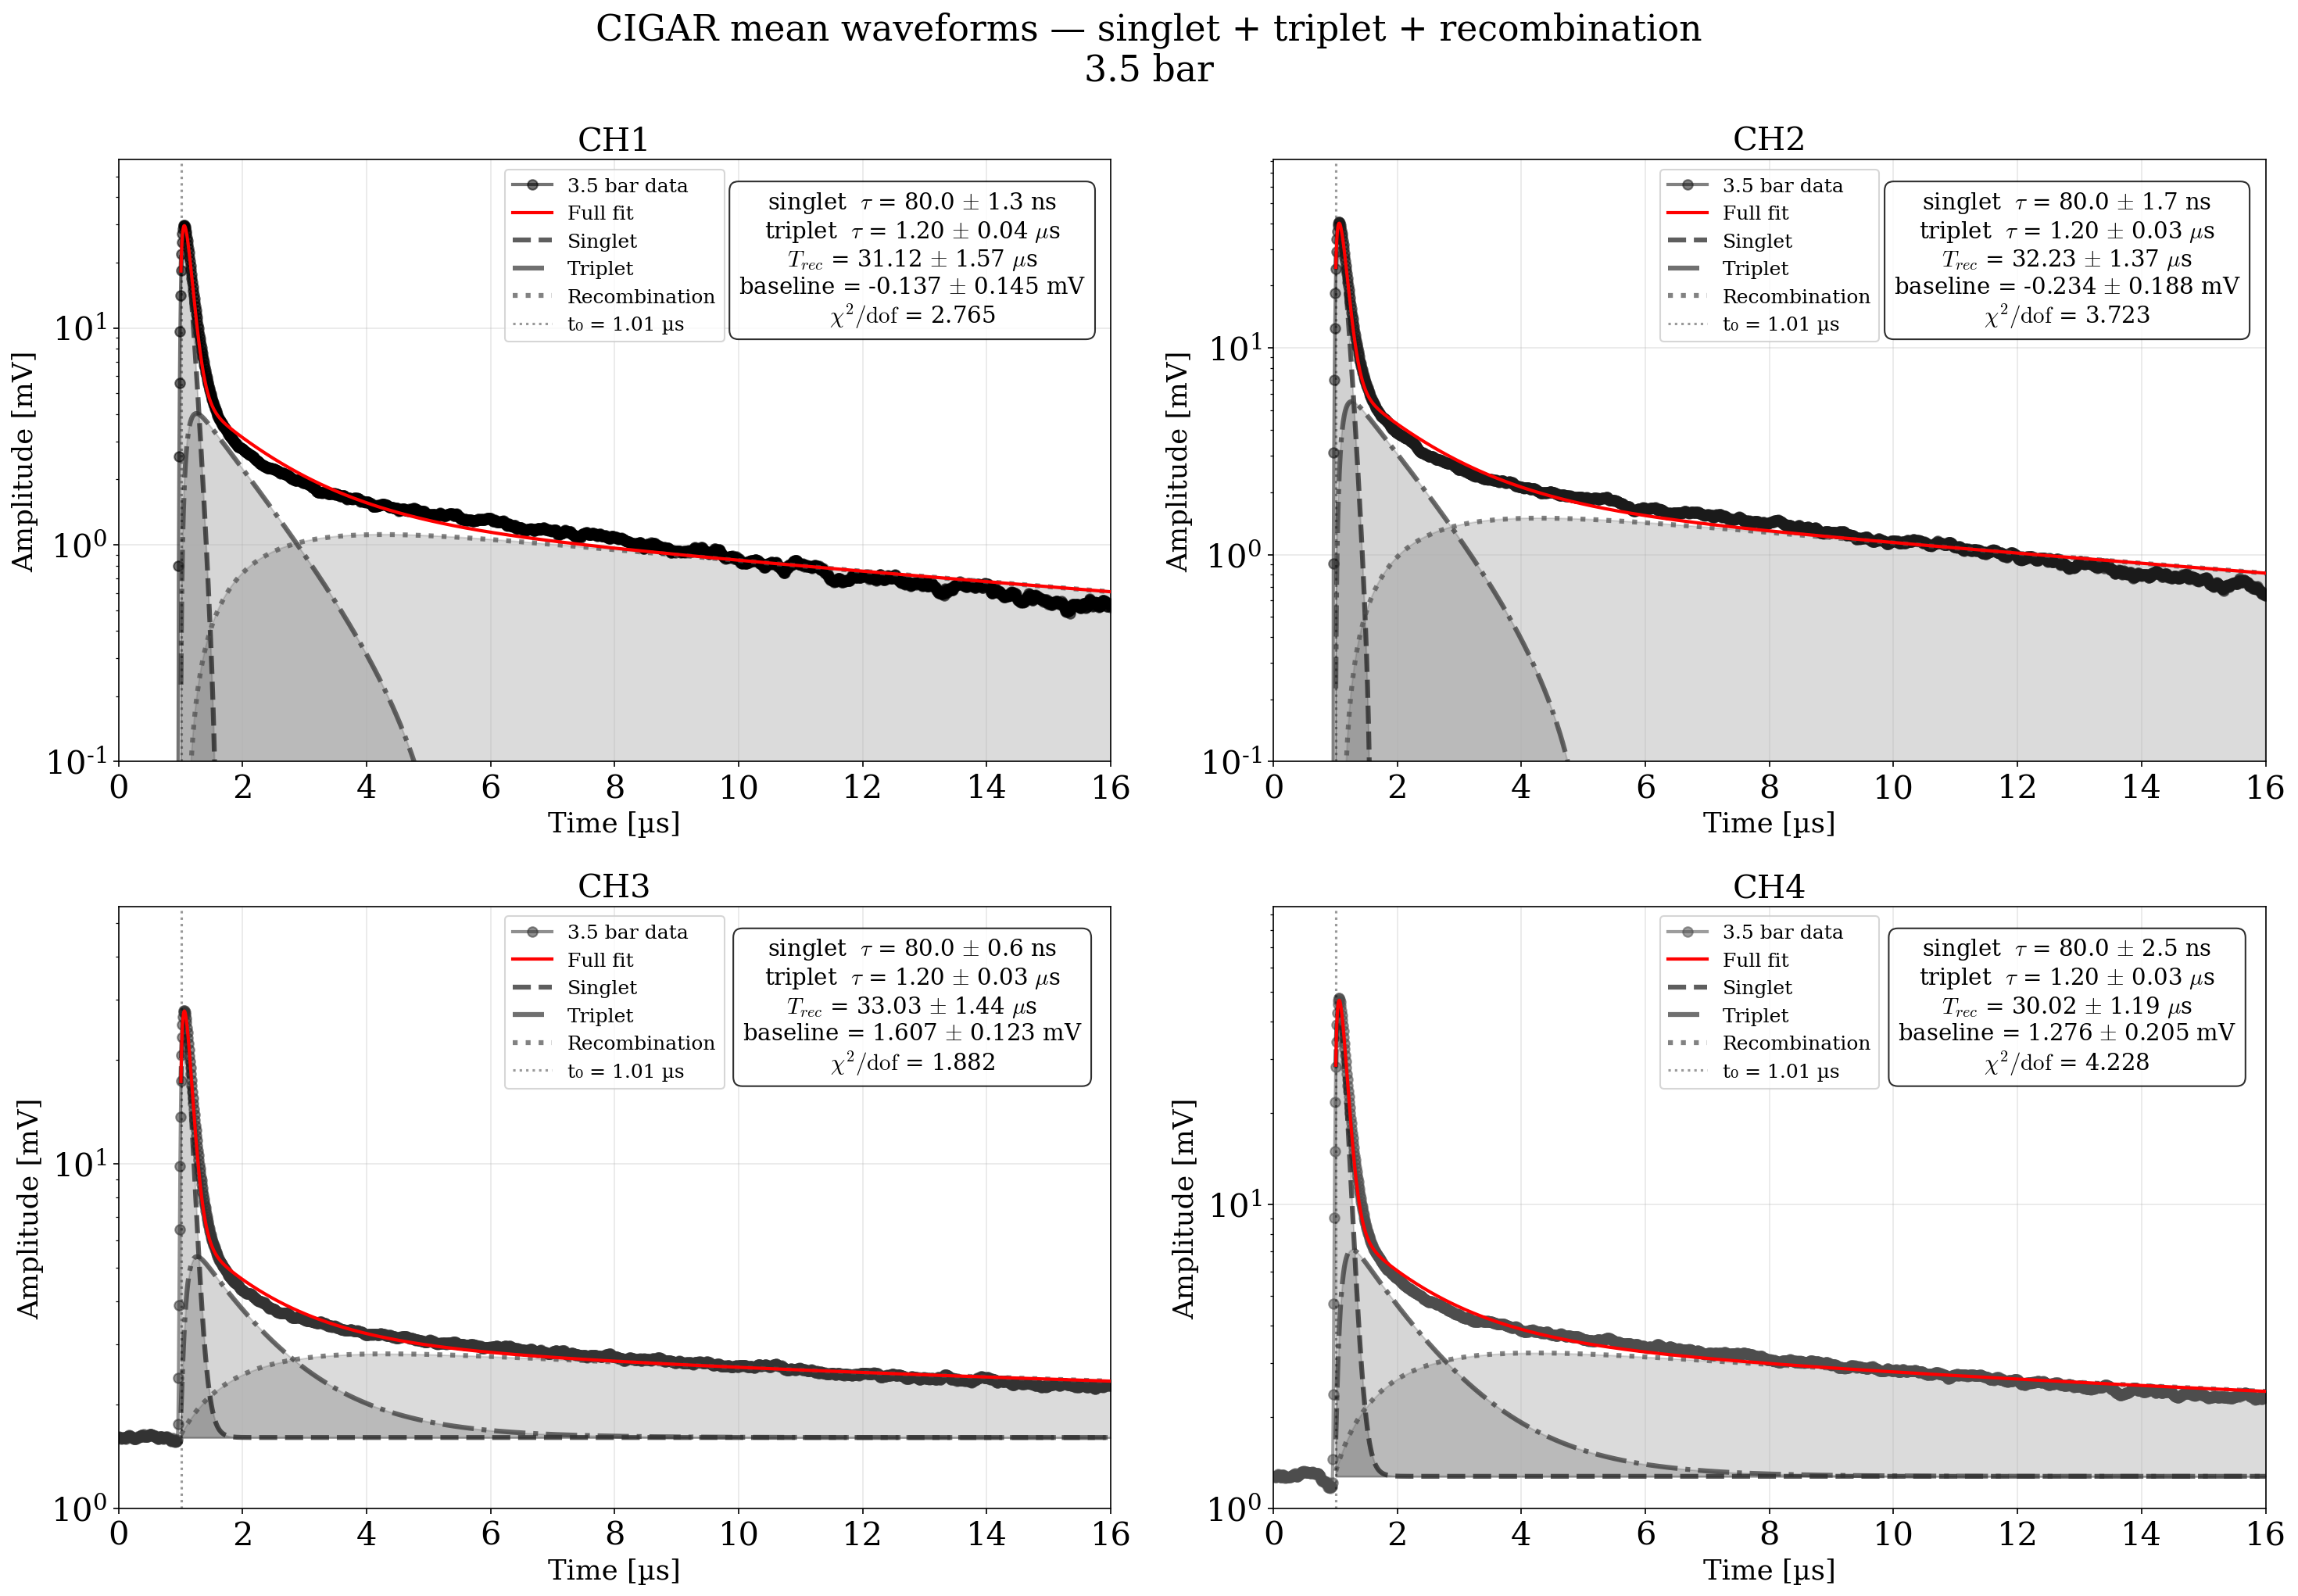


--- CH1 @ 2.5 bar  [fit result] ---
Parameter                   Lower        Initial          Upper  In bounds?          Fitted   Clip-lo%  Clip-hi%
------------------------------------------------------------------------------------------------------------------------------
t0                     9.2800e-07 1.0080e-06     1.0880e-06           ✓      9.8471e-07     35.44%    64.56%
A_singlet              2.1509e-06 1.0754e-05     3.0112e-05           ✓      5.3913e-06     11.59%    88.41%
tau_singlet            2.5000e-08 3.9000e-08     8.0000e-08           ✓      8.0000e-08    100.00%    0.00% ⚠
A_triplet              0.0000e+00 3.2263e-05     4.0866e-05           ✓      9.0044e-06     22.03%    77.97%
rise_triplet           3.0000e-08 1.5000e-07     3.0000e-07           ✓      4.5642e-08      5.79%    94.21%
tau_triplet            1.2000e-06 2.1600e-06     2.8000e-06           ✓      1.2000e-06     0.00% ⚠   100.00%
A_rec                  8.4174e-07 4.2087e-06     4.0142e-05        

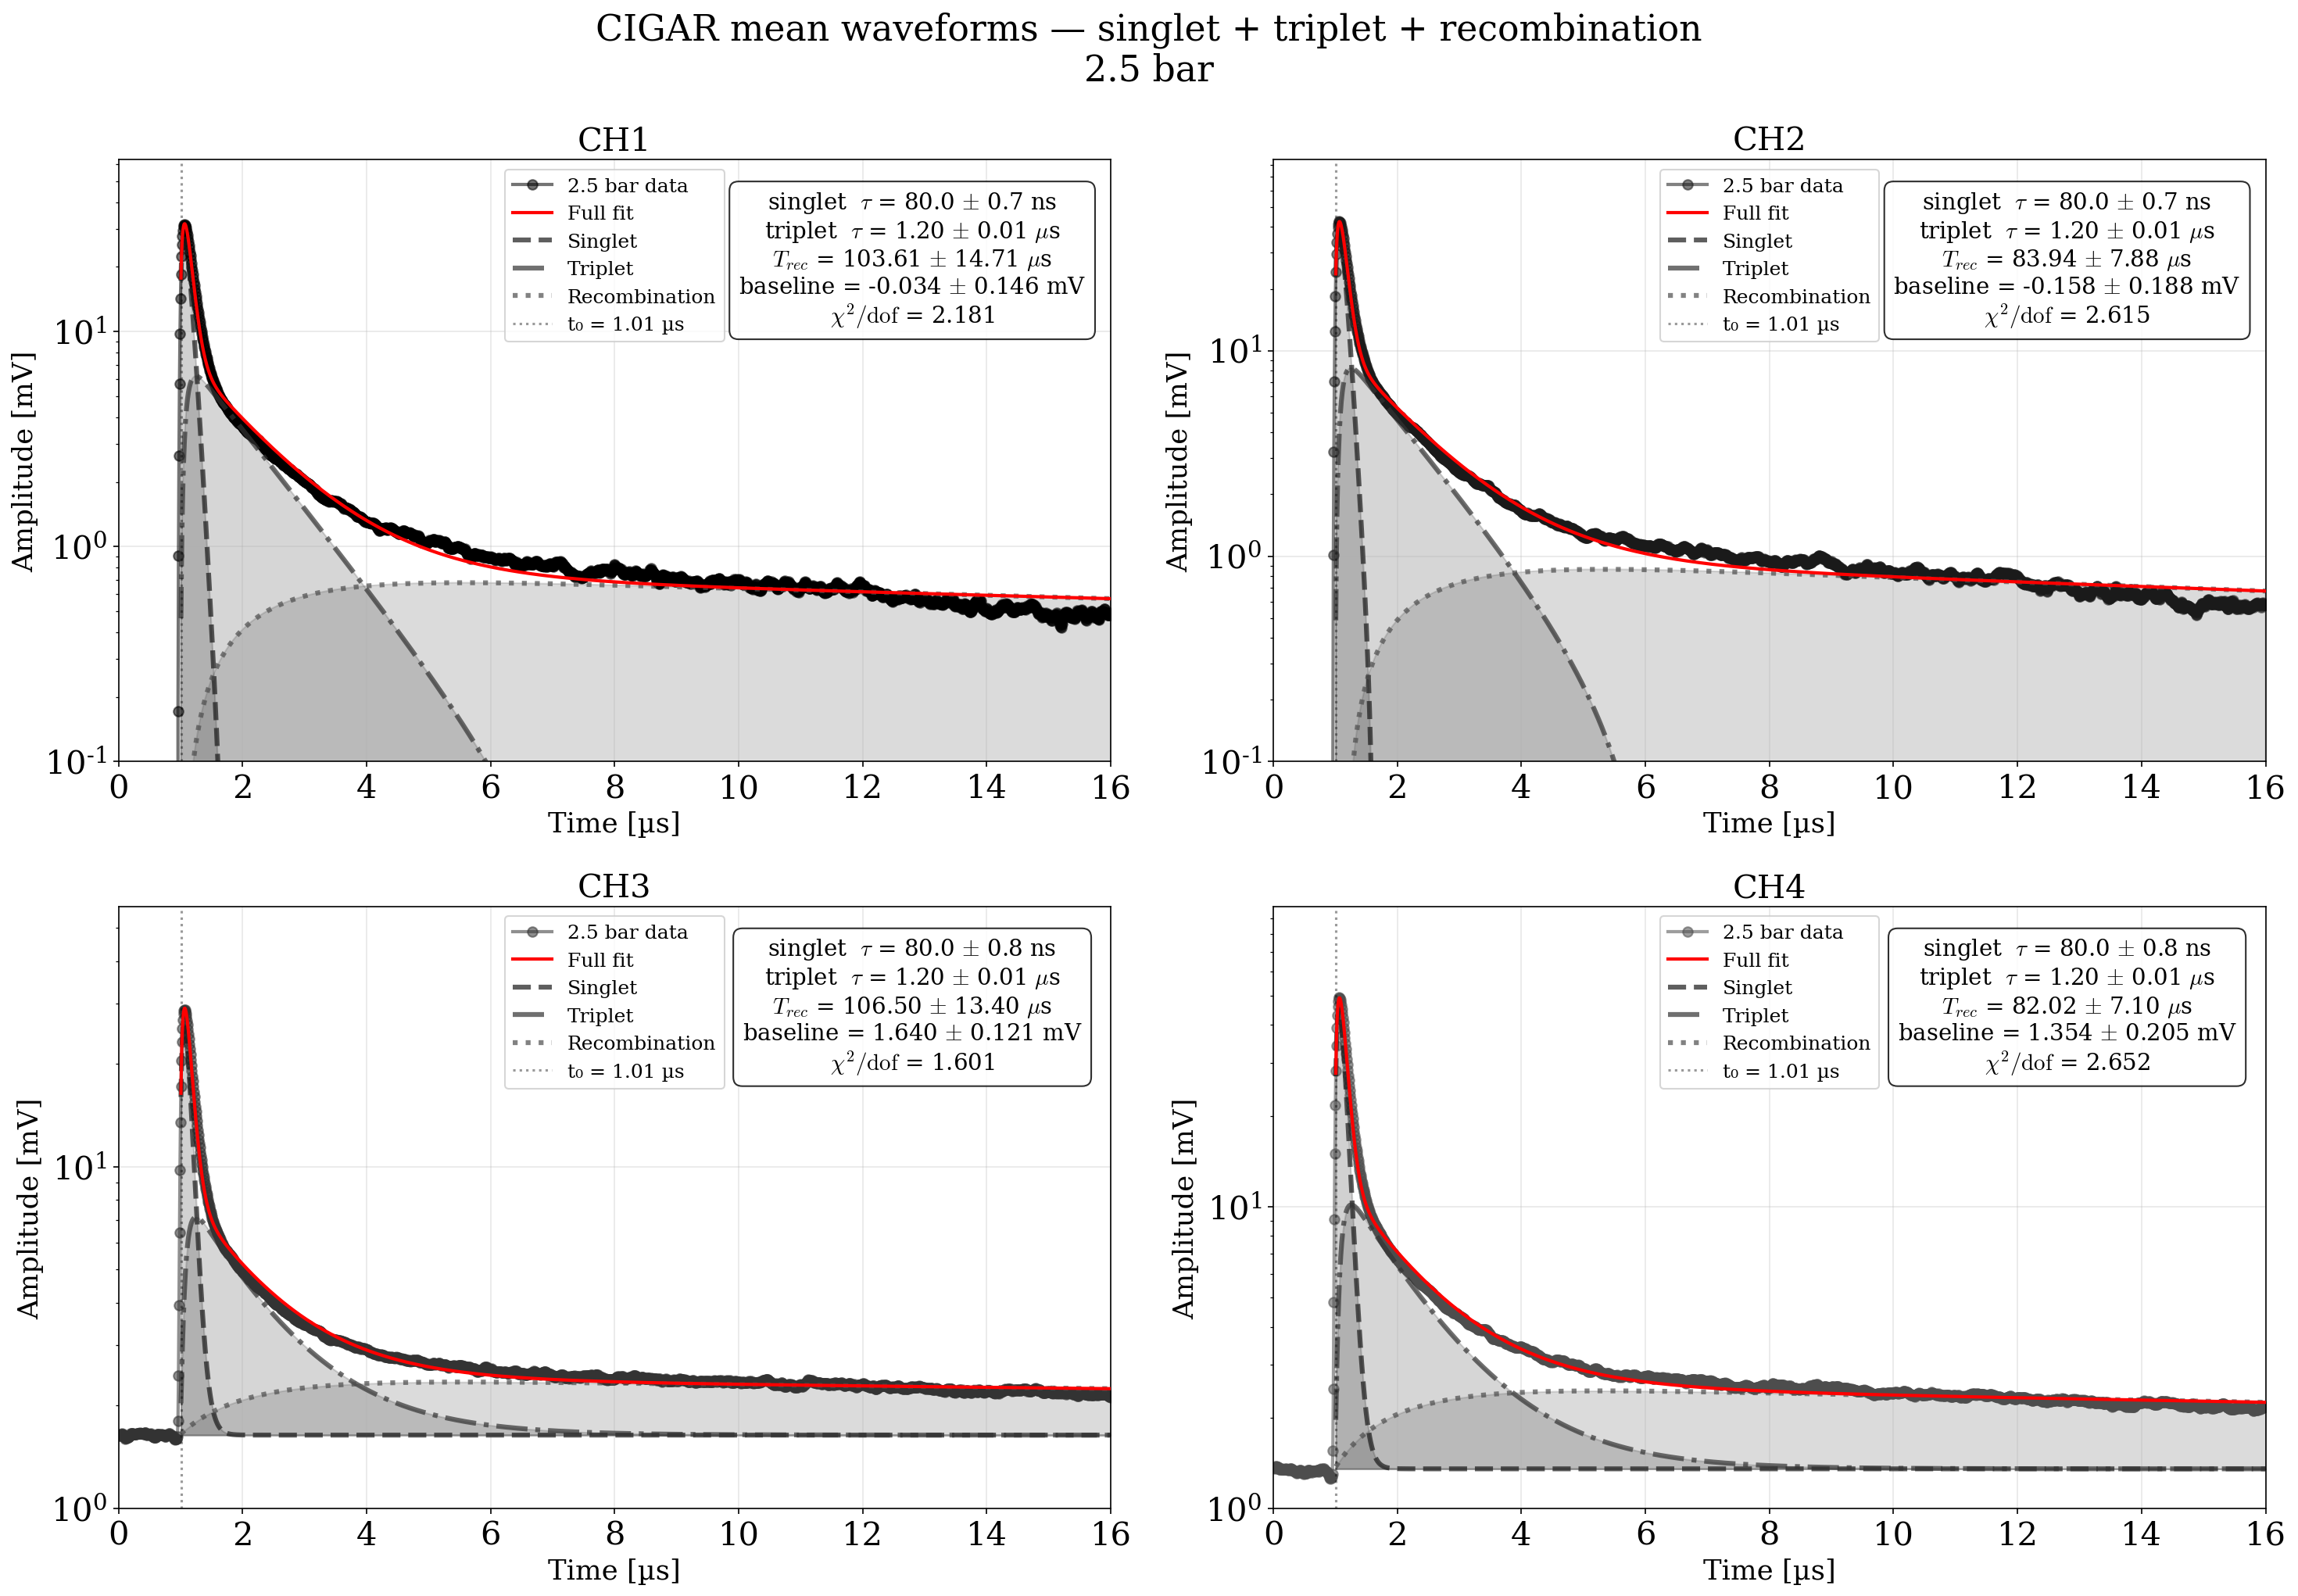


--- CH1 @ 1.5 bar  [fit result] ---
Parameter                   Lower        Initial          Upper  In bounds?          Fitted   Clip-lo%  Clip-hi%
------------------------------------------------------------------------------------------------------------------------------
t0                     9.2800e-07 1.0080e-06     1.0880e-06           ✓      9.8872e-07     37.95%    62.05%
A_singlet              2.1593e-06 1.0796e-05     3.0230e-05           ✓      5.1361e-06     10.60%    89.40%
tau_singlet            2.5000e-08 3.9000e-08     8.0000e-08           ✓      7.9996e-08     99.99%    0.01% ⚠
A_triplet              0.0000e+00 3.2389e-05     4.1026e-05           ✓      1.2136e-05     29.58%    70.42%
rise_triplet           3.0000e-08 1.5000e-07     3.0000e-07           ✓      4.4556e-08      5.39%    94.61%
tau_triplet            1.2000e-06 2.1600e-06     2.8000e-06           ✓      1.2001e-06     0.01% ⚠    99.99%
A_rec                  2.3470e-07 1.1735e-06     3.7705e-05        

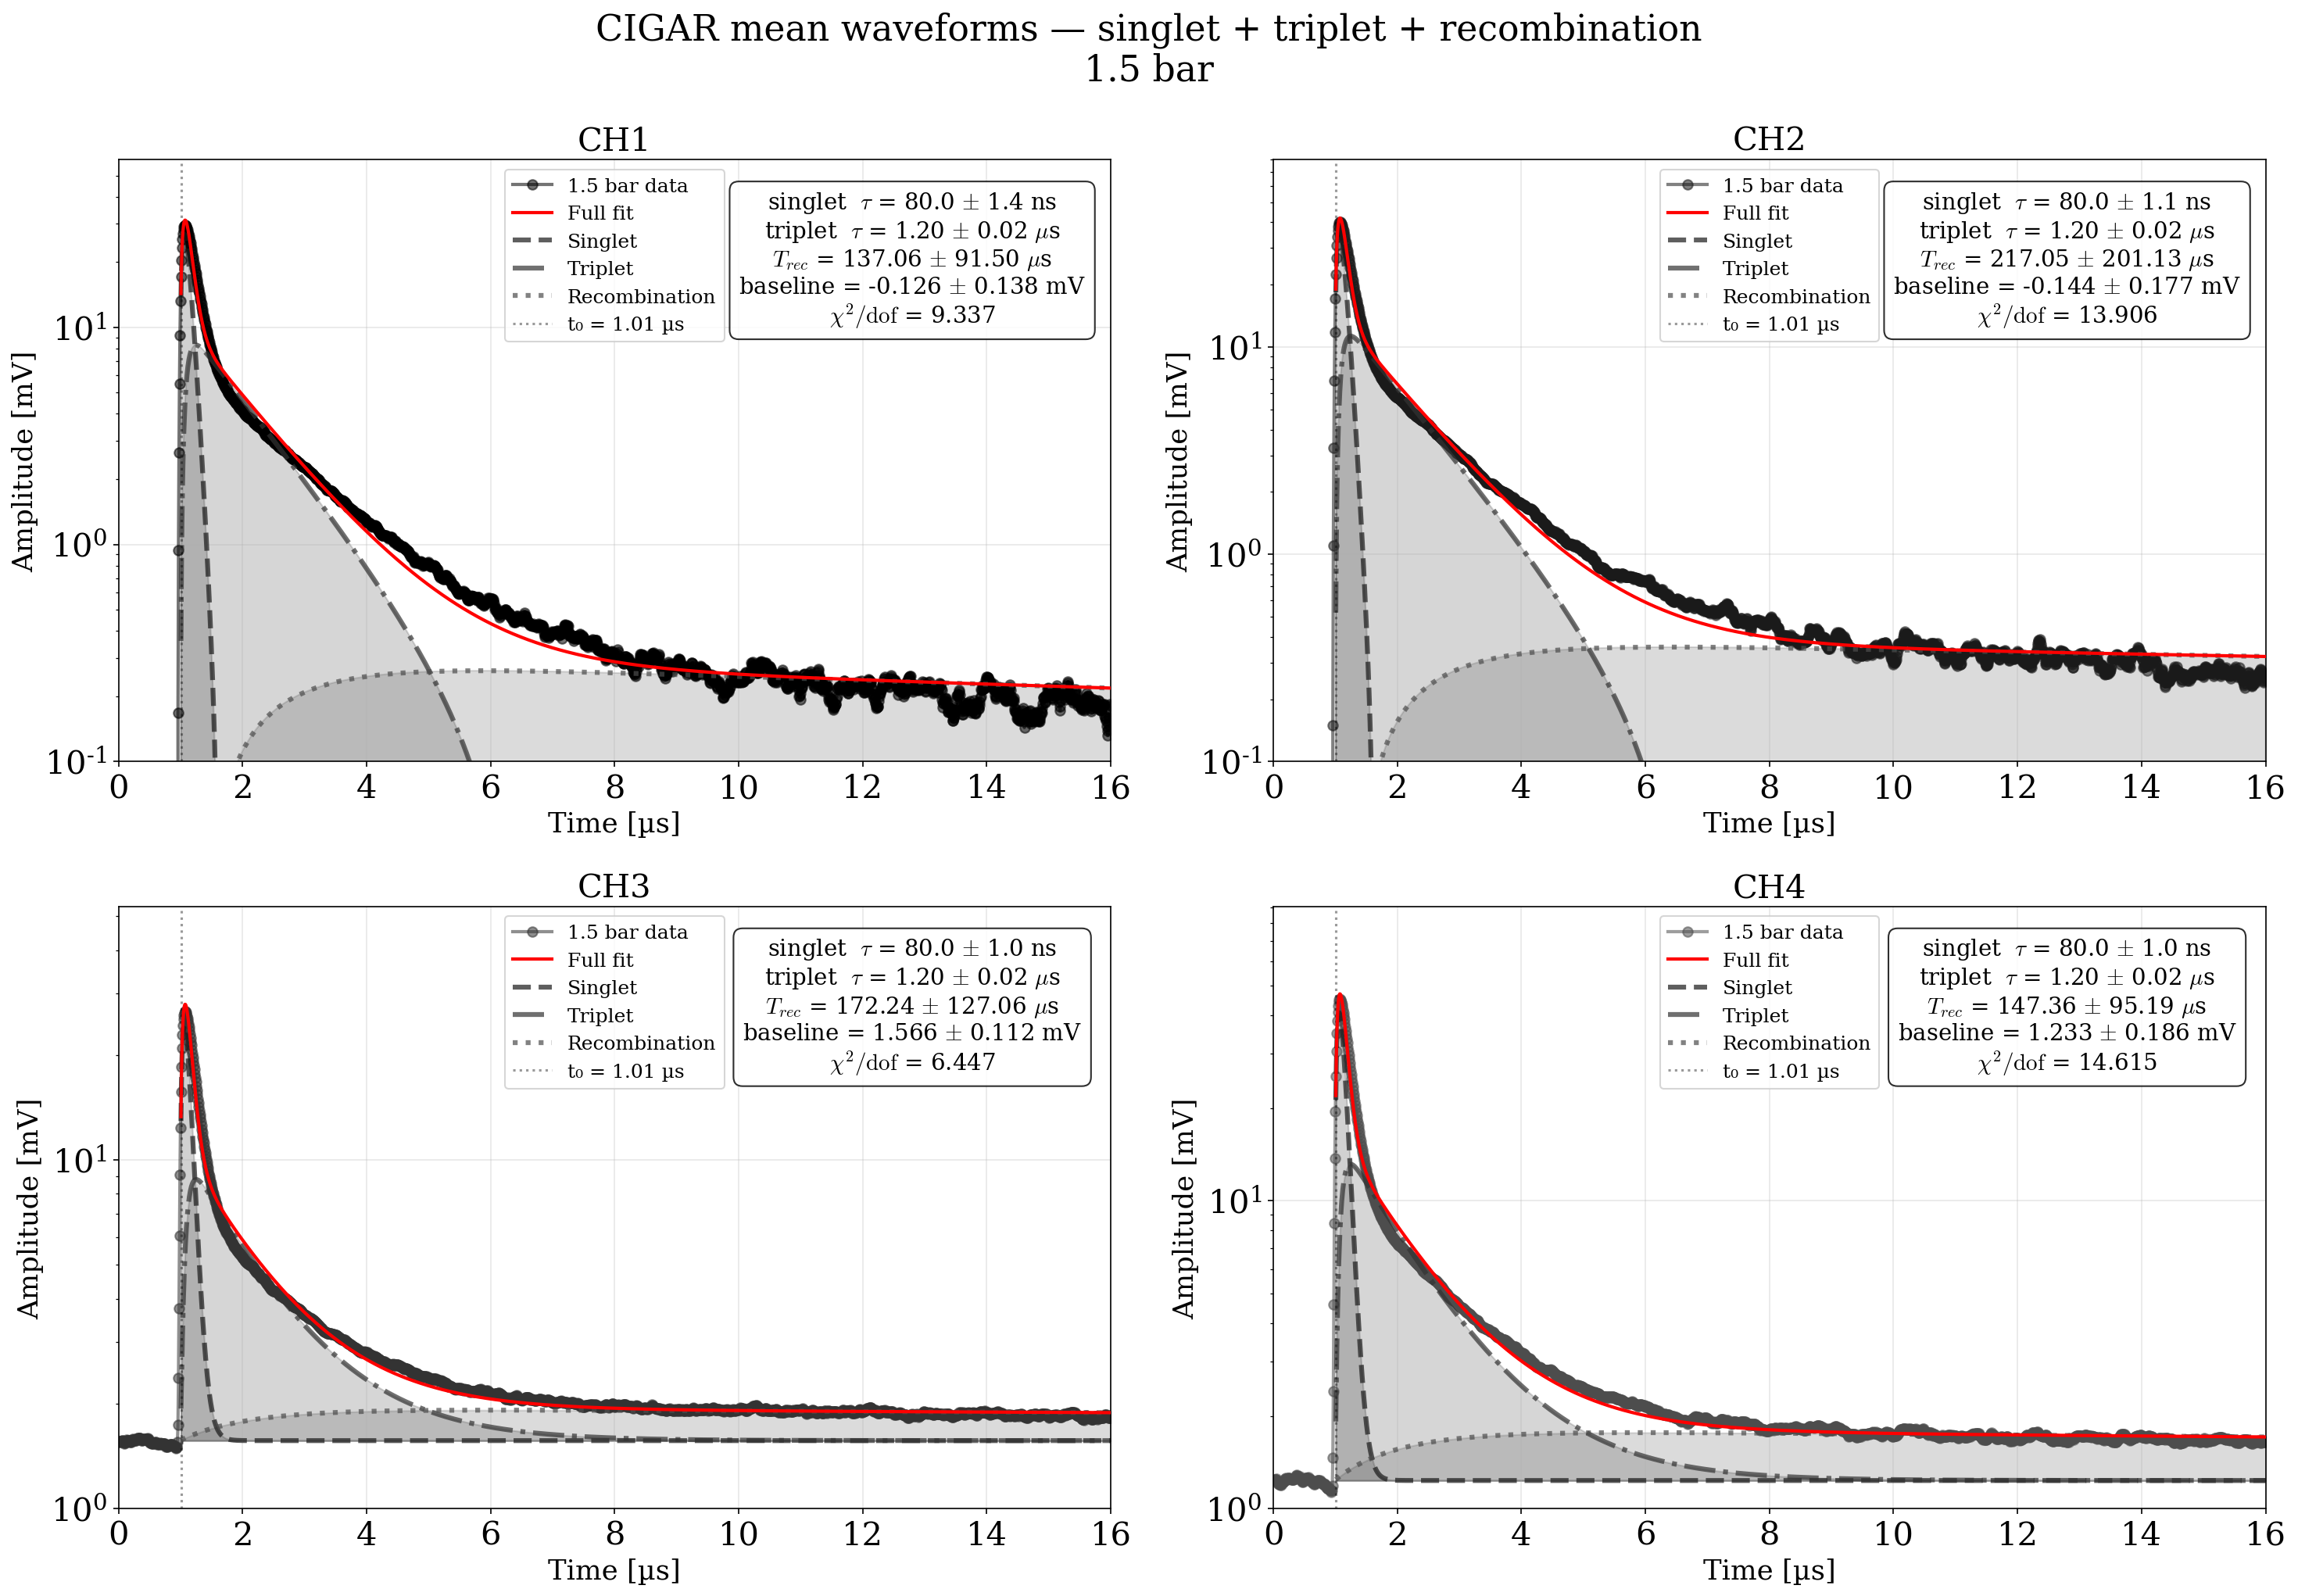


DONE!


In [244]:
# singlet, triplet, recombination per channel per pressure
singlet_decay, triplet_decay = {}, {}
rec_tau, rec_Tr = {}, {}

# Store waveform/fit arrays for the final summary figure
all_fits = {}  # {bars: {sphe_key: {t_fit, wf_fit, wf_model, h_singlet, h_triplet, h_rec, bl, fit_ok}}}

prev_cp = None  # warm-start from previous (higher) pressure


for bars, run_name in sorted(runs.items(), reverse=True):   # 8.5 -> 1.5 bar
    run = {bars: run_name}

    # Build warm-start p0 from previous pressure result.
    # 8-param layout: t0=0, As=1, ts=2, At=3, rt=4, tt=5, Ar=6, Tr=7
    p0_warm = None
    if prev_cp is not None:
        p0_warm = {
            f"CH{i+1}": [
                prev_cp[f"CH{i+1}"]["t0"],
                prev_cp[f"CH{i+1}"]["A_singlet"],  prev_cp[f"CH{i+1}"]["tau_singlet"],
                prev_cp[f"CH{i+1}"]["A_triplet"],  prev_cp[f"CH{i+1}"]["rise_triplet"],
                prev_cp[f"CH{i+1}"]["tau_triplet"],
                prev_cp[f"CH{i+1}"]["A_rec"] * 0.9, prev_cp[f"CH{i+1}"]["Tr"],
            ]
            for i in range(4) if f"CH{i+1}" in prev_cp
        }

    fig, axs_cig, cp = fit_cigar_waveforms(run, base, pretrigger_sample=pretrigger,
                                           channels_to_show=None, invert=True,
                                           p0_cigar=p0_warm, bounds_cigar=None,
                                           colors=colors, font_size=20, logscale=True,
                                           check_bounds=False)
    plt.show()

    if check_aprox_validity:
        for ch, p in cp.items():
            print(f"\n=== {ch}  @  {bars} bar ===")
            check_timescale_validity(p["tau_singlet"], p["tau_triplet"], p["Tr"])

    # reload raw waveforms and reconstruct branches for summary figure
    run_name_fmt = run_name if not isinstance(run_name, int) else f"Run{run_name}"
    npz          = np.load(f"{base}/mean_waveforms/mean_waveforms_{run_name_fmt}.npz", allow_pickle=True)
    channels_arr = npz["channels"]
    time_arr     = npz["time"]
    all_fits[bars] = {}

    for ch_idx, ch in enumerate(channels_arr):
        sk = f"CH{ch_idx+1}"
        if sk not in cp: continue
        p    = cp[sk]
        wf   = -npz[f"ch_{ch}"].copy()
        fit_mask = time_arr >= time_arr[125]
        t_fit    = time_arr[fit_mask]
        wf_fit   = wf[fit_mask]

        t0_ = p["t0"]
        As, rs, ts = p["A_singlet"], p["rise_singlet"], p["tau_singlet"]
        At, rt, tt = p["A_triplet"], p["rise_triplet"], p["tau_triplet"]
        Ar, taur, Tr_ = p["A_rec"], p["tau_rec"], p["Tr"]
        bl = p["baseline"]

        u    = t_fit - t0_
        mask = u > 0

        h_s       = np.zeros_like(t_fit)
        h_s[mask] = _conv_two_rise_decay(u[mask], rs, ts, 1e-9, 64e-9)
        area = np.trapz(h_s, x=t_fit)
        if area > 0: h_s *= As / area

        h_t       = np.zeros_like(t_fit)
        h_t[mask] = _conv_two_rise_decay(u[mask], rt, tt, 1e-9, 64e-9)
        area = np.trapz(h_t, x=t_fit)
        if area > 0: h_t *= At / area

        h_r      = Ar * recombination_model(t_fit, t0_, taur, Tr_)
        wf_model = CIGARResponse_analytical(t_fit, t0_, As, rs, ts, At, rt, tt, Ar, taur, Tr_, bl)

        all_fits[bars][sk] = dict(
            t_fit=t_fit, wf_fit=wf_fit, wf_model=wf_model,
            h_singlet=h_s, h_triplet=h_t, h_rec=h_r,
            bl=bl, fit_ok=not np.any(np.isnan(p["pcov"])),
        )

    # accumulate decay-time tables
    # pcov is 8×8 (indices 0–7): t0=0, As=1, ts=2, At=3, rt=4, tt=5, Ar=6, Tr=7
    for ch in cp:
        cov  = cp[ch]["pcov"]
        cond = np.linalg.cond(cov) if not np.any(np.isnan(cov)) else np.inf

        if ch not in singlet_decay:
            singlet_decay[ch] = {}; triplet_decay[ch] = {}
            rec_tau[ch]       = {}; rec_Tr[ch]        = {}

        def _safe_err(cov_mat, idx):
            """Extract sqrt(cov[idx,idx]), returning nan if not finite."""
            val = cov_mat[idx, idx]
            return float(np.sqrt(val)) if np.isfinite(val) and val >= 0 else float('nan')

        singlet_decay[ch][bars] = (cp[ch]["tau_singlet"], _safe_err(cov, 2))  # ts index 2
        triplet_decay[ch][bars] = (cp[ch]["tau_triplet"], _safe_err(cov, 5))  # tt index 5
        rec_tau[ch][bars]       = (cp[ch]["tau_rec"],     _safe_err(cov, 5))  # tau_rec = tt index 5
        rec_Tr[ch][bars]        = (cp[ch]["Tr"],          _safe_err(cov, 7))  # Tr index 7

    # prev_cp = cp
    prev_cp = None


print("\nDONE!")

In [245]:
1e-7*1e9

100.0

In [246]:
cp['CH2']

{'t0': 9.888979279809404e-07,
 'A_singlet': 6.869953863944301e-06,
 'rise_singlet': 1e-09,
 'tau_singlet': 7.999970611049613e-08,
 'A_triplet': 1.6458745605615264e-05,
 'rise_triplet': 4.299914029971352e-08,
 'tau_triplet': 1.2000479431295566e-06,
 'A_rec': 6.834026483781617e-06,
 'tau_rec': 1.2000479431295566e-06,
 'Tr': 0.00021704743498301903,
 'baseline': -0.14363502986151688,
 'pcov': array([[ 3.95991969e-19,  1.57833718e-16,  1.89601800e-19,
         -1.46969038e-16,  1.09310399e-17,  1.91920148e-18,
         -1.08821800e-17,  9.41132403e-15],
        [ 1.57833718e-16,  9.63832609e-14,  2.58121370e-16,
         -8.36159284e-14,  6.45652721e-15,  2.16954733e-15,
         -1.24829272e-14,  1.10248511e-11],
        [ 1.89601800e-19,  2.58121370e-16,  1.26067346e-18,
         -1.94855968e-16,  1.61992201e-17,  1.08904985e-17,
         -6.33781464e-17,  5.64814729e-14],
        [-1.46969038e-16, -8.36159284e-14, -1.94855968e-16,
          9.59442563e-14, -5.74786633e-15,  3.87658103e-1

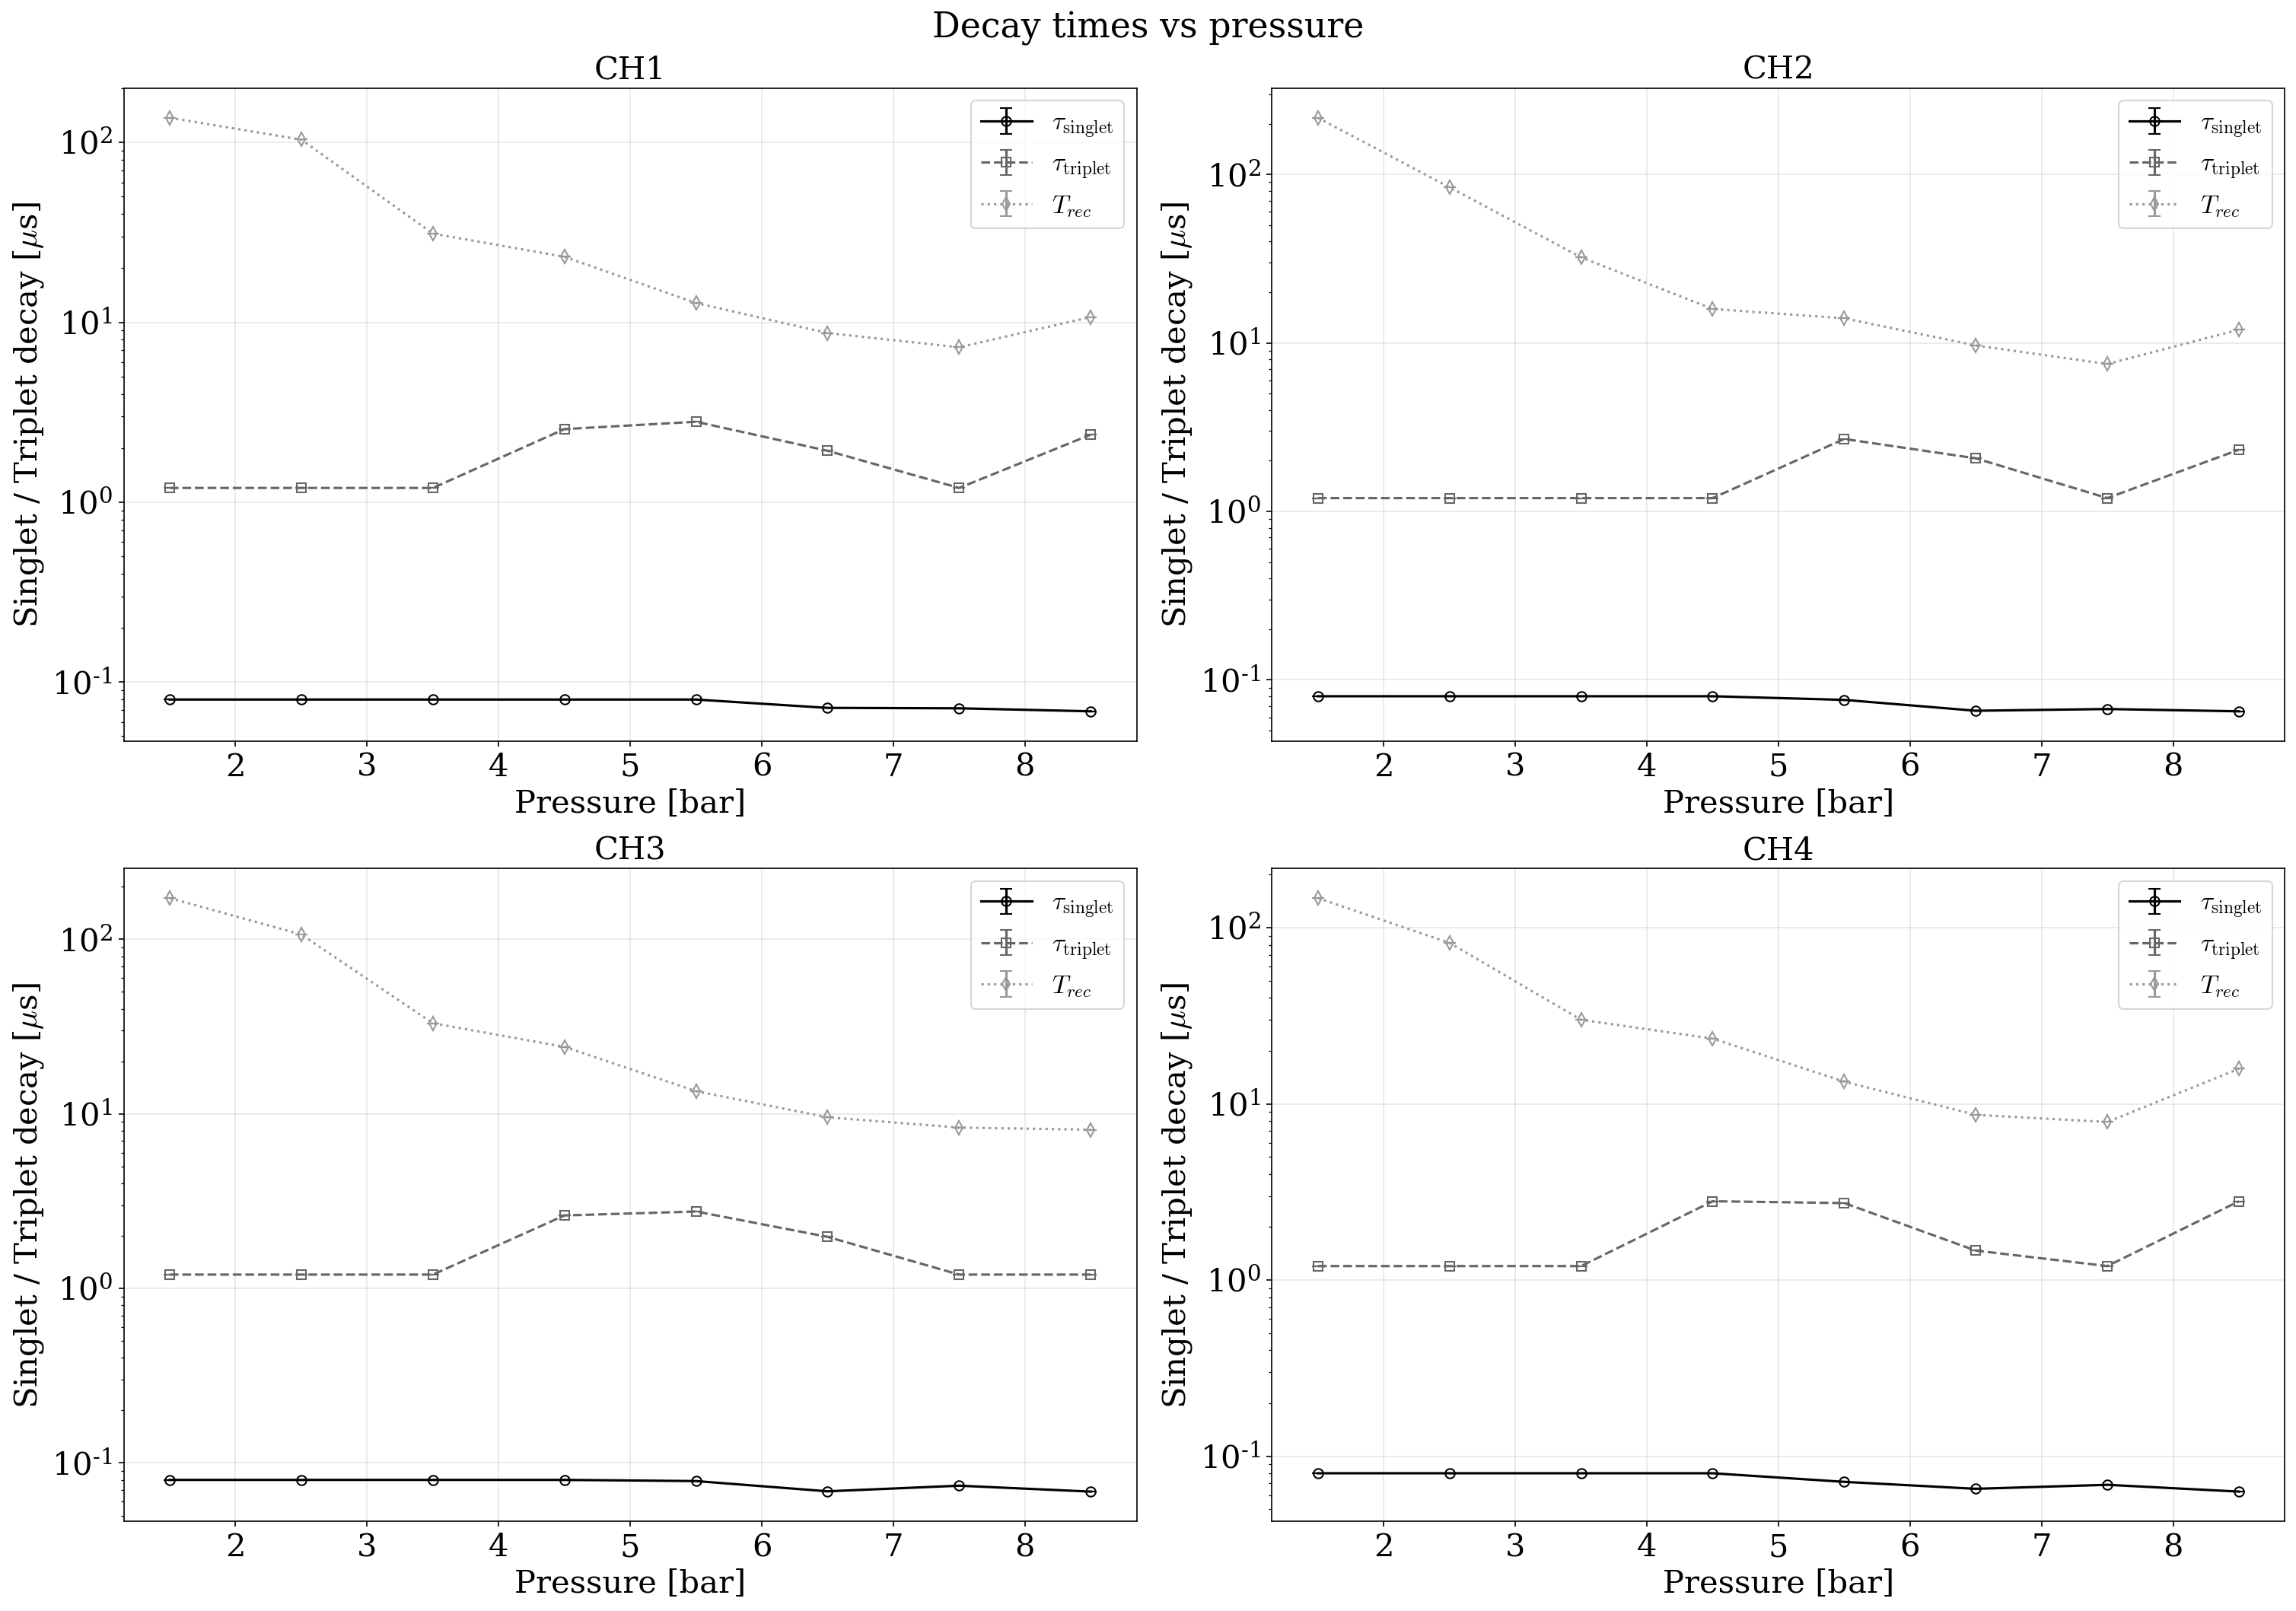

SINGLET AND TRIPLET ARE BOTH IN [us] AND FOLLOWING ax ALTHOUGH THE UNITS IN ax ARE WRONG NOW


In [247]:
# Decay times vs pressure — always in B&W for publication clarity
_gs = GS_COLORS

fig, axs = plt.subplots(2, 2, figsize=(20, 14), dpi=150, constrained_layout=True)
fig.suptitle("Decay times vs pressure", fontsize=font_size + 2)

for ii, ch in enumerate(sorted(singlet_decay.keys())):
    ax  = axs.flat[ii]
    # ax2 = ax.twinx()
    bars_list    = sorted(singlet_decay[ch].keys())
    tau_singlet  = np.array([singlet_decay[ch][b][0] for b in bars_list]) * 1e6
    err_singlet  = np.array([singlet_decay[ch][b][1] for b in bars_list]) * 1e6
    tau_triplet  = np.array([triplet_decay[ch][b][0] for b in bars_list]) * 1e6
    err_triplet  = np.array([triplet_decay[ch][b][1] for b in bars_list]) * 1e6
    Tr_rec_vals  = np.array([rec_Tr[ch][b][0]       for b in bars_list]) * 1e6
    err_rec_vals = np.array([rec_Tr[ch][b][1]       for b in bars_list]) * 1e6
    # errors NOT capped — shown as-is so unreliable fits are visible

    ax.errorbar(bars_list, tau_singlet, 
                # yerr=err_singlet,
                yerr=0,
                fmt="o-",  color=_gs[0], markerfacecolor="none",
                label=r"$\tau_\mathrm{singlet}$", capsize=4)
    ax.errorbar(bars_list, tau_triplet, 
                #  yerr=err_triplet,
                 yerr=0,
                 fmt="s--", color=_gs[4], markerfacecolor="none",
                 label=r"$\tau_\mathrm{triplet}$", capsize=4)
    ax.errorbar(bars_list, Tr_rec_vals, 
                #  yerr=err_rec_vals,
                 yerr=0,
                 fmt="d:",  color=_gs[6], markerfacecolor="none",
                 label=r"$T_{rec}$", capsize=4)

    ax.set_title(ch, fontsize=font_size)
    ax.set_xlabel("Pressure [bar]", fontsize=font_size)
    ax.set_ylabel(r"Singlet / Triplet decay [$\mu$s]", fontsize=font_size, color=_gs[0])
    ax.tick_params(axis="y", labelcolor=_gs[0])
    # ax2.set_ylabel(r"Recombination [$\mu$s]",
                #    fontsize=font_size, rotation=270, labelpad=25)
    # ax2.yaxis.label.set_color(_gs[4])
    # ax2.tick_params(axis="y", labelcolor=_gs[4])
    # ax2.spines["right"].set_color(_gs[4])
    ax.grid(True, alpha=0.3)
    lines1, labels1 = ax.get_legend_handles_labels()
    # lines2, labels2 = ax2.get_legend_handles_labels()
    # ax.legend(lines1+labels1+lines2+labels2, lines1+labels1+lines2+labels2,
    #           fontsize=font_size*0.8, loc="upper right")
    # ax.legend(lines1+lines2, labels1+labels2, fontsize=font_size*0.8, loc="upper right")
    ax.legend(lines1, labels1, fontsize=font_size*0.8, loc="upper right")

    ax.set_yscale('log')
    # ax2.set_yscale('log')

plt.show()

print("SINGLET AND TRIPLET ARE BOTH IN [us] AND FOLLOWING ax ALTHOUGH THE UNITS IN ax ARE WRONG NOW")

##  Summary figure — all pressures per channel

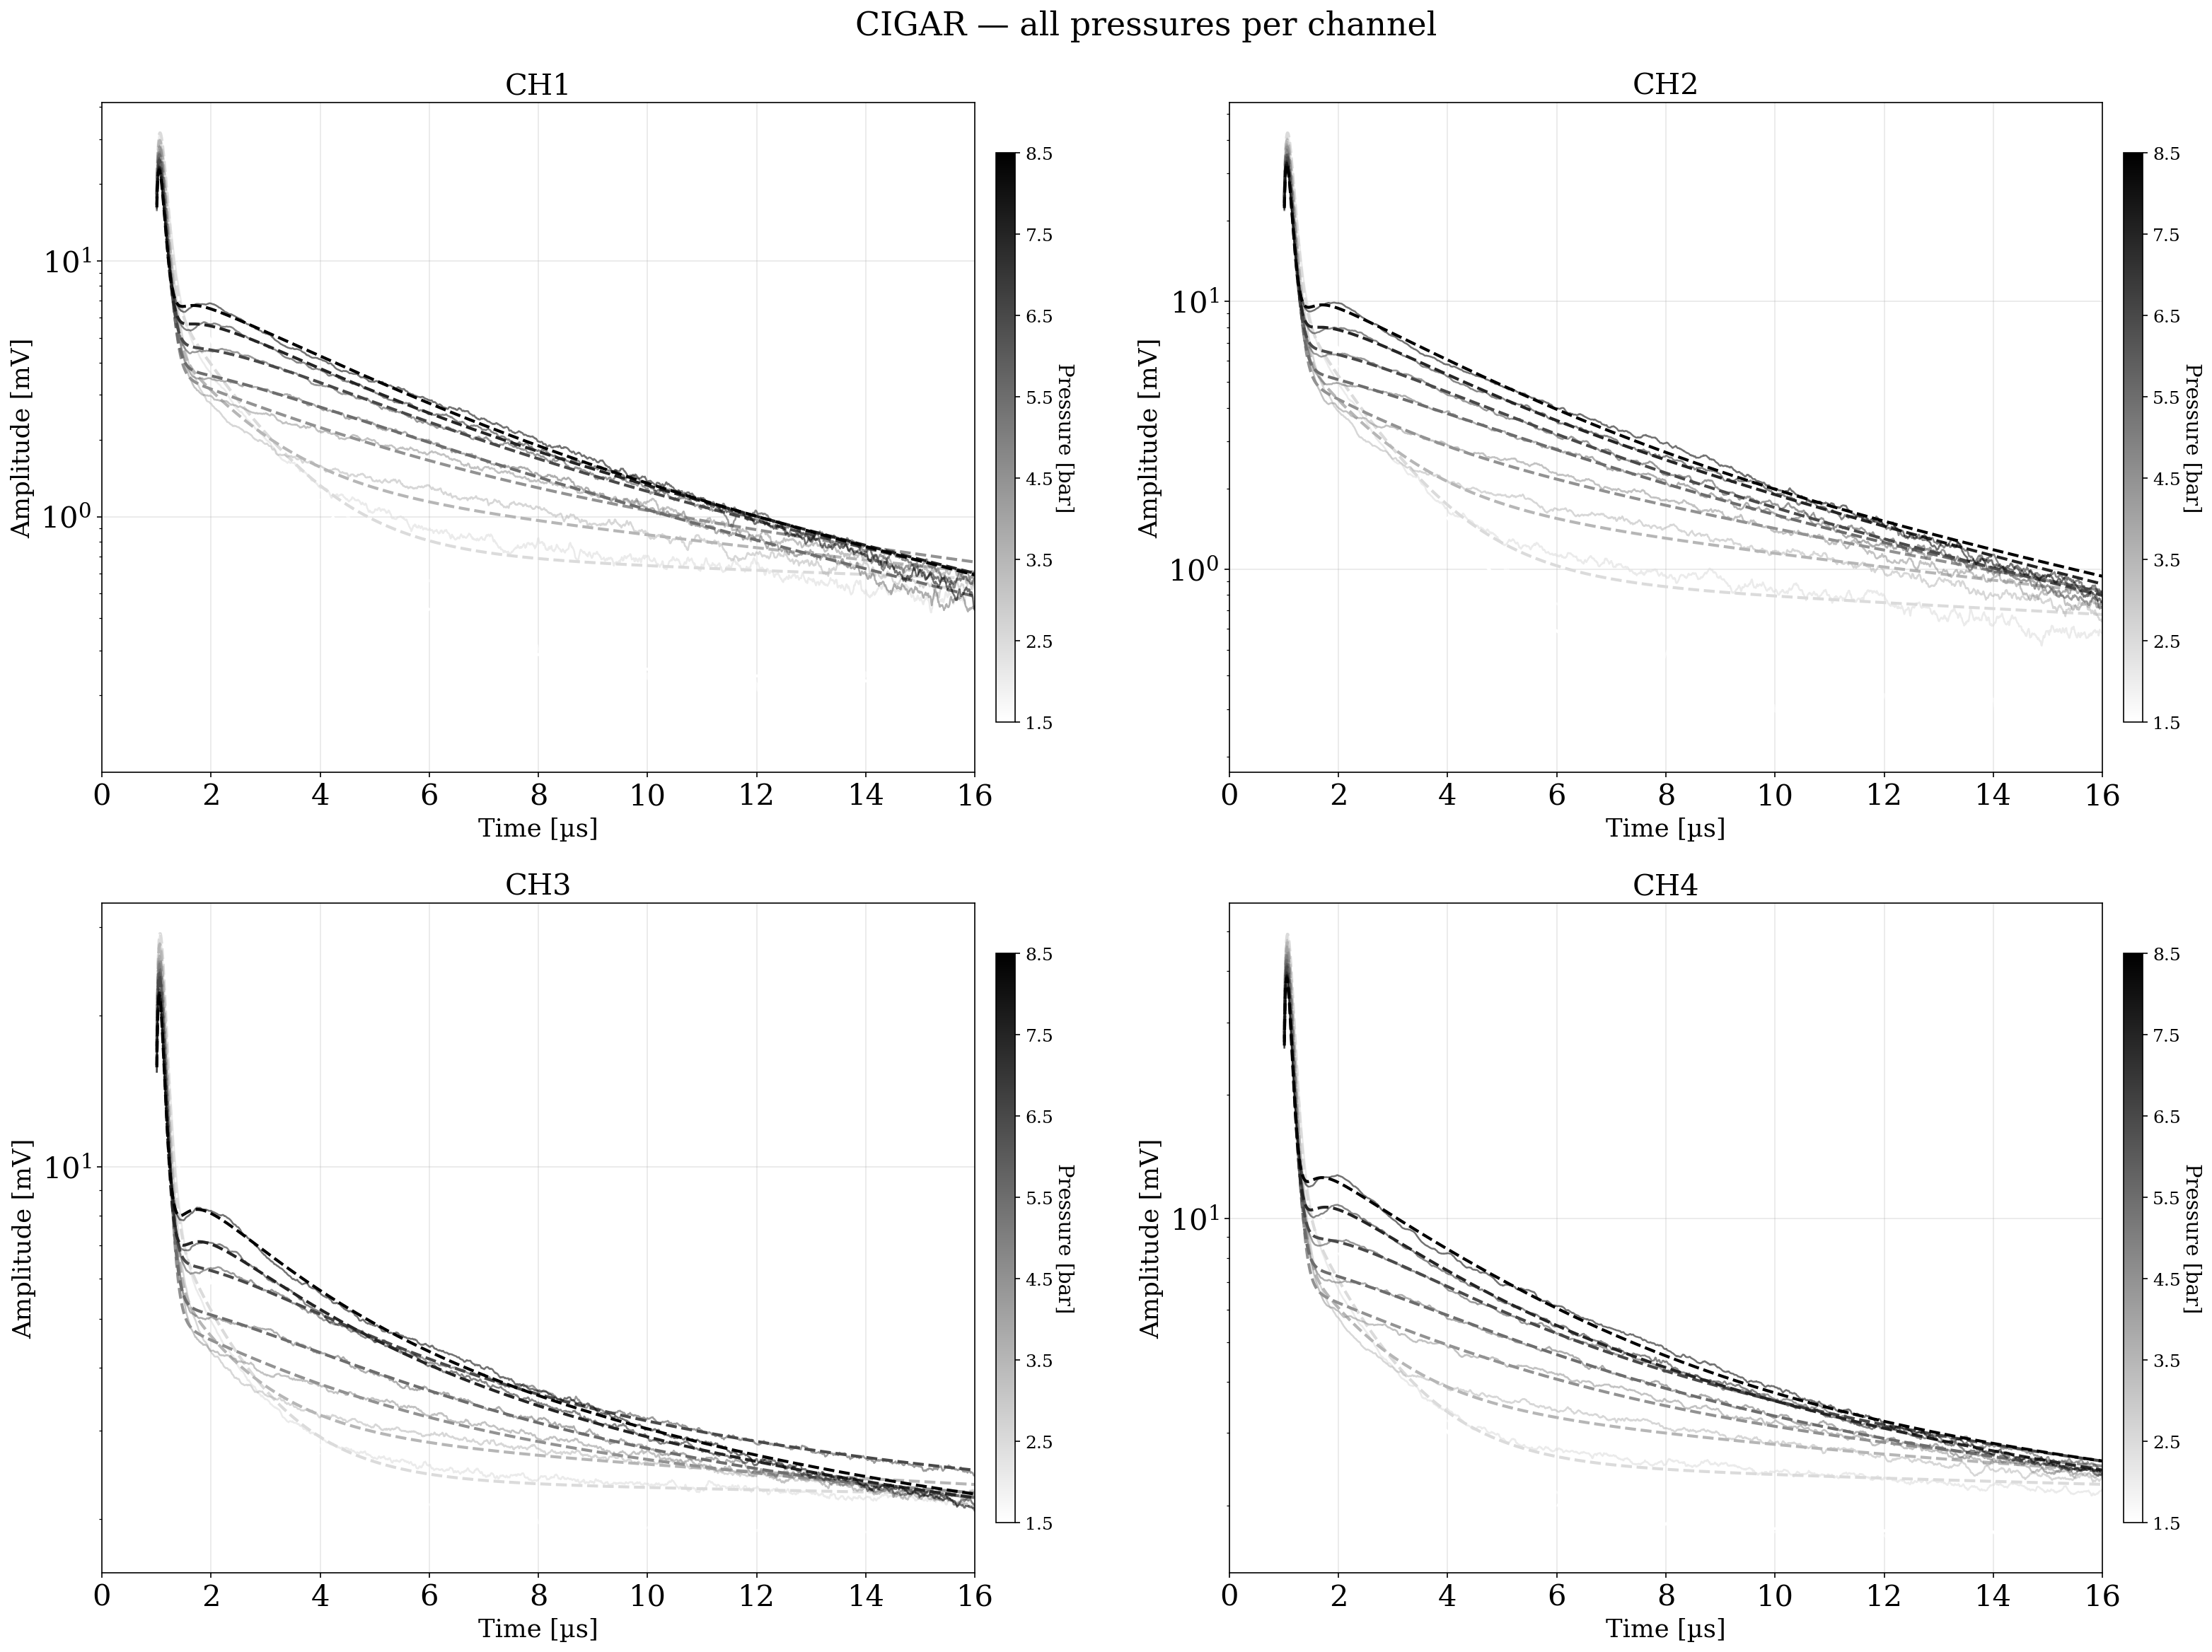

In [248]:
# =========================================================================== #
#  SUMMARY FIGURE                                                              #
#  2x2 grid, one panel per channel.                                           #
#  Each panel: all waveforms + fits coloured by pressure (grey colorbar),     #
#  with an inset showing tau_singlet, tau_triplet and Tr vs pressure.         #
# =========================================================================== #
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.cm as mcm
import matplotlib.colors as mcolors

pressures_sorted = sorted(all_fits.keys())   # low -> high

# grey colormap: low pressure = light, high pressure = dark
cmap      = mcm.get_cmap("gray_r")
norm      = mcolors.Normalize(vmin=min(pressures_sorted), vmax=max(pressures_sorted))
press2col = lambda p: cmap(norm(p))

channels_ordered = sorted(
    {ch for bar_data in all_fits.values() for ch in bar_data},
    key=lambda x: int(x[2:])
)

fig_sum, axs_sum = plt.subplots(2, 2, figsize=(22, 16), dpi=150)
fig_sum.suptitle("CIGAR — all pressures per channel", fontsize=font_size + 2)

for panel_i, ch in enumerate(channels_ordered[:4]):
    ax = axs_sum.flat[panel_i]

    # main panel: waveforms + fits coloured by pressure
    for bars in pressures_sorted:
        if ch not in all_fits.get(bars, {}): continue
        d   = all_fits[bars][ch]
        col = press2col(bars)
        ax.semilogy(d["t_fit"]*1e6, d["wf_fit"],   lw=1.2, alpha=0.55, color=col)
        if d["fit_ok"]:
            ax.semilogy(d["t_fit"]*1e6, d["wf_model"], lw=2.0, ls="--", color=col)

    ax.set_xlabel("Time [µs]", fontsize=font_size * 0.85)
    ax.set_ylabel("Amplitude [mV]", fontsize=font_size * 0.85)
    ax.set_title(ch, fontsize=font_size)
    ax.set_xlim(0, 16)
    ax.grid(True, alpha=0.3)

    # colorbar — shrink pad to leave more room for the inset
    sm   = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig_sum.colorbar(sm, ax=ax, pad=0.02, aspect=30, shrink=0.85)
    cbar.set_label("Pressure [bar]", fontsize=font_size*0.70, rotation=270, labelpad=14)
    cbar.set_ticks(pressures_sorted)
    cbar.ax.tick_params(labelsize=font_size*0.60)

    # ── inset: tau_singlet (left axis, ns) and tau_triplet + Tr (right axis, µs) ──
    # Use axes fraction coordinates directly — width/height as fraction of parent ax.
    # Place in lower-right quadrant to avoid the waveform peak at t~1 µs.
    # ax_in = ax.inset_axes([0.35, 0.50, 0.58, 0.45])   # [x0, y0, width, height] in axes coords
    # ax_in2 = ax_in.twinx()

    bars_list = sorted(singlet_decay.get(ch, {}).keys())
    if bars_list:
        tau_s = np.array([singlet_decay[ch][b][0] for b in bars_list]) * 1e9
        err_s = np.array([singlet_decay[ch][b][1] for b in bars_list]) * 1e9
        tau_t = np.array([triplet_decay[ch][b][0] for b in bars_list]) * 1e6
        err_t = np.array([triplet_decay[ch][b][1] for b in bars_list]) * 1e6
        # Tr (recombination characteristic time), NOT tau_rec
        Tr_vals = np.array([rec_Tr[ch][b][0] for b in bars_list]) * 1e6
        err_Tr  = np.array([rec_Tr[ch][b][1] for b in bars_list]) * 1e6

        # ax_in.errorbar(bars_list, tau_s, yerr=err_s,
        #                fmt="o-",  color="black",   ms=3, lw=1.1, capsize=2,
        #                label=r"$\tau_{s}$")
        # ax_in2.errorbar(bars_list, tau_t, yerr=err_t,
        #                 fmt="s--", color="#555555", ms=3, lw=1.1, capsize=2,
        #                 label=r"$\tau_{t}$")
        # ax_in2.errorbar(bars_list, Tr_vals, yerr=err_Tr,
        #                 fmt="d:",  color="#999999", ms=3, lw=1.1, capsize=2,
        #                 label=r"$T_r$")

        # ax_in.set_xlabel("P [bar]",             fontsize=font_size*0.48)
        # ax_in.set_ylabel(r"$\tau_s$ [ns]",      fontsize=font_size*0.48, color="black")
        # ax_in2.set_ylabel(r"$\tau_t$, $T_r$ [µs]", fontsize=font_size*0.48,
        #                    color="#555555", rotation=270, labelpad=10)
        # ax_in.tick_params(labelsize=font_size*0.42)
        # ax_in2.tick_params(labelsize=font_size*0.42, labelcolor="#555555")
        # ax_in2.yaxis.label.set_color("#555555")
        # ax_in.set_yscale("log")
        # ax_in2.set_yscale("log")

        # background so inset reads cleanly over the waveforms
        # ax_in.patch.set_facecolor("white")
        # ax_in.patch.set_alpha(0.85)

        # lines1, labs1 = ax_in.get_legend_handles_labels()
        # lines2, labs2 = ax_in2.get_legend_handles_labels()
        # ax_in.legend(lines1+lines2, labs1+labs2,
        #              fontsize=font_size*0.42, loc="upper right",
        #              framealpha=0.90, handlelength=1.2)
        # ax_in.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()